# 부산 대중교통 노선 최적화 분석
**KAIA 2단계 - 버스 노선 효율성 분석 및 심야 정류소 수요 분석**

---

## 분석 목차
- **Part 0.** 환경 설정 + 전체 데이터 로드 + 통일 PK 체계
- **Part 1.** 하차 추정 알고리즘
- **Part 2.** 시나리오 1 - 노선 선택 → 수정 추천 노선 5개 제안
- **Part 3.** 시나리오 2 - 심야 버스 정류소 필요 지점 표시
- **Part 4.** 종합 결과 저장

---
**v2.0 변경사항:**
1. 시나리오 1: 노선 입력 → 해당 노선 수정 대안 5개 제안
2. 시나리오 2: 심야 정류소 필요 위치만 표시 (노선 설계 X)
3. grid-읍면동 매핑 추가
4. 전체 통일 PK 체계 적용

---
## Part 0. 환경 설정 + 전체 데이터 로드

In [61]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union, nearest_points
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree
import networkx as nx
import os, zipfile, glob

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 기본 경로 (Windows PC)
BASE = r'C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터'
TARGET_CRS = 'EPSG:5179'
RESULT_DIR = f'{BASE}\\results_optimization'
os.makedirs(RESULT_DIR, exist_ok=True)

print('환경 설정 완료')
print(f'작업 경로: {BASE}')
print(f'결과 저장 경로: {RESULT_DIR}')

환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터
결과 저장 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터\results_optimization


### 0.1 버스 노선 데이터

In [62]:
# 버스노선.csv 로드
bus_routes = pd.read_csv(f'{BASE}\\버스노선.csv', encoding='utf-8-sig')
bus_routes.columns = bus_routes.columns.str.strip().str.replace('\ufeff', '')

print(f'총 행수: {len(bus_routes):,}')
print(f'고유 노선 수: {bus_routes["노선번호"].nunique()}')
print(f'고유 정류소 수: {bus_routes["정류소ID"].nunique()}')
print(f'\n컬럼: {list(bus_routes.columns)}')
bus_routes.head()

총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


In [63]:
# 노선 유형 분류
def classify_route(name):
    name = str(name)
    if '심야' in name:
        return '심야버스'
    elif '아침' in name or '출' in name:
        return '출퇴근버스'
    elif name.startswith(('1001','1002','1003','1004')):
        return '급행버스'
    else:
        try:
            int(name)
            return '시내버스'
        except:
            return '마을버스'

route_list = bus_routes.groupby('노선번호').agg(
    정류소수=('정류소순번', 'max'),
    시작정류소=('정류소명', 'first'),
    종료정류소=('정류소명', 'last')
).reset_index()

route_list['노선유형'] = route_list['노선번호'].apply(classify_route)

print('=== 노선 유형별 현황 ===')
print(route_list['노선유형'].value_counts())
print(f'\n노선당 평균 정류소 수: {route_list["정류소수"].mean():.1f}')

=== 노선 유형별 현황 ===
노선유형
마을버스     178
시내버스     125
심야버스      15
급행버스       4
출퇴근버스      4
Name: count, dtype: int64

노선당 평균 정류소 수: 75.4


### 0.2 버스 노선 GeoDataFrame 생성

In [64]:
# 버스노선 정류소를 GeoDataFrame으로 변환
bus_routes_gdf = gpd.GeoDataFrame(
    bus_routes,
    geometry=gpd.points_from_xy(bus_routes['GPS_X'], bus_routes['GPX_Y']),
    crs='EPSG:4326'
).to_crs(TARGET_CRS)

print(f'버스 노선 GeoDataFrame: {len(bus_routes_gdf):,}건, CRS: {bus_routes_gdf.crs}')

# 노선별 LineString 생성 (정류소 순서대로 연결)
route_lines = {}
for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    coords = list(group.geometry.apply(lambda g: (g.x, g.y)))
    if len(coords) >= 2:
        route_lines[route_id] = LineString(coords)

route_lines_gdf = gpd.GeoDataFrame(
    {'노선번호': list(route_lines.keys())},
    geometry=list(route_lines.values()),
    crs=TARGET_CRS
)
print(f'노선 LineString 수: {len(route_lines_gdf)}')

버스 노선 GeoDataFrame: 24,576건, CRS: EPSG:5179
노선 LineString 수: 326


### 0.3 공간 데이터 로드

In [65]:
# 버스 정류소 SHP
bus_stops_shp = gpd.read_file(f'{BASE}\\부산광역시_버스 정류소 정보(SHP)_20250121\\tl_bus_station_info.shp')
if bus_stops_shp.crs.to_epsg() != 5179:
    bus_stops_shp = bus_stops_shp.to_crs(TARGET_CRS)
print(f'버스 정류소 SHP: {len(bus_stops_shp):,}건, CRS: {bus_stops_shp.crs}')

# 50m 격자
grid_50m = gpd.read_file(f'{BASE}\\50m_grid\\busan_50cell_v21.shp')
if grid_50m.crs.to_epsg() != 5179:
    grid_50m = grid_50m.to_crs(TARGET_CRS)
print(f'50m 격자: {len(grid_50m):,}건, CRS: {grid_50m.crs}')

# 집계구 경계
census = gpd.read_file(f'{BASE}\\집계구경계\\집계구경계.shp')
if census.crs.to_epsg() != 5179:
    census = census.to_crs(TARGET_CRS)
print(f'집계구: {len(census):,}건, CRS: {census.crs}')

버스 정류소 SHP: 8,522건, CRS: EPSG:5179
50m 격자: 310,241건, CRS: EPSG:5179
집계구: 6,802건, CRS: EPSG:5179


### 0.3.1 Grid-읍면동 매핑 + 통일 PK 체계

50m 격자 데이터와 읍면동(행정동) 데이터를 공간 조인으로 매핑하고,
전체 데이터 테이블을 연결하는 통일 PK 체계를 구축합니다.

**PK 체계:**

| 테이블 | PK | 포맷 |
|--------|-----|------|
| 격자 | GRID_PK | GRD_{grid_id} |
| 읍면동 | EMD_PK | EMD_{ADM_CD 8자리} |
| 정류소 | STOP_PK | STP_{bstopid} |
| 노선 | ROUTE_PK | RTE_{노선번호} |
| 노드 | NODE_PK | NDE_{NODE_ID} |
| 링크 | LINK_PK | LNK_{LINK_ID} |

In [66]:
# ===========================================================
# Grid-읍면동 매핑 (Spatial Join) + 통일 PK 체계
# ===========================================================
print('=== Grid-읍면동 매핑 + PK 체계 구축 ===')

# --- 1. 읍면동 경계 생성 (집계구 ADM_CD 기반 dissolve) ---
census['EMD_CD'] = census['ADM_CD'].astype(str).str[:8]
emd_boundary = census.dissolve(by='EMD_CD').reset_index()
emd_boundary = emd_boundary[['EMD_CD', 'geometry']]
print(f'읍면동 경계: {len(emd_boundary)}개')

# --- 2. Grid → 읍면동 Spatial Join ---
grid_centroids = grid_50m.copy()
grid_centroids['centroid'] = grid_centroids.geometry.centroid
grid_centroids_pt = grid_centroids.set_geometry('centroid')

grid_emd = gpd.sjoin(
    grid_centroids_pt[['id', 'centroid']],
    emd_boundary,
    how='left',
    predicate='within'
)
grid_emd = grid_emd.drop_duplicates(subset='id', keep='first')
grid_emd = grid_emd[['id', 'EMD_CD']].reset_index(drop=True)
print(f'Grid-읍면동 매핑: {grid_emd["EMD_CD"].notna().sum():,}/{len(grid_emd):,} ({grid_emd["EMD_CD"].notna().mean()*100:.1f}%)')

# --- 3. 통일 PK 생성 ---
grid_50m['GRID_PK'] = 'GRD_' + grid_50m['id'].astype(str)
emd_boundary['EMD_PK'] = 'EMD_' + emd_boundary['EMD_CD'].astype(str)
bus_stops_shp['STOP_PK'] = 'STP_' + bus_stops_shp['bstopid'].astype(str)
bus_routes_gdf['STOP_PK'] = 'STP_' + bus_routes_gdf['정류소ID'].astype(str)
bus_routes_gdf['ROUTE_PK'] = 'RTE_' + bus_routes_gdf['노선번호'].astype(str)
grid_emd['GRID_PK'] = 'GRD_' + grid_emd['id'].astype(str)
grid_emd['EMD_PK'] = grid_emd['EMD_CD'].apply(lambda x: f'EMD_{x}' if pd.notna(x) else None)

# --- 4. 정류소-읍면동 매핑 ---
stop_emd = gpd.sjoin(
    bus_stops_shp[['STOP_PK', 'bstopid', 'bstopnm', 'geometry']],
    emd_boundary[['EMD_CD', 'EMD_PK', 'geometry']],
    how='left', predicate='within'
).drop_duplicates(subset='STOP_PK', keep='first')
stop_emd = stop_emd[['STOP_PK', 'EMD_CD', 'EMD_PK']].reset_index(drop=True)
print(f'정류소-읍면동 매핑: {stop_emd["EMD_CD"].notna().sum():,}/{len(stop_emd):,}')

# --- 5. 정류소-Grid 매핑 ---
_gc = np.column_stack([grid_50m.geometry.centroid.x, grid_50m.geometry.centroid.y])
_gt = cKDTree(_gc)
_sc = np.column_stack([bus_stops_shp.geometry.x, bus_stops_shp.geometry.y])
_, _si = _gt.query(_sc)
bus_stops_shp['nearest_GRID_PK'] = grid_50m.iloc[_si]['GRID_PK'].values

print(f'\n=== PK 체계 요약 ===')
print(f'  GRID_PK: {len(grid_50m):,}개 | EMD_PK: {len(emd_boundary):,}개')
print(f'  STOP_PK: {len(bus_stops_shp):,}개 | ROUTE_PK: {bus_routes_gdf["ROUTE_PK"].nunique():,}개')

=== Grid-읍면동 매핑 + PK 체계 구축 ===
읍면동 경계: 205개
Grid-읍면동 매핑: 308,074/310,241 (99.3%)
정류소-읍면동 매핑: 7,943/8,522

=== PK 체계 요약 ===
  GRID_PK: 310,241개 | EMD_PK: 205개
  STOP_PK: 8,522개 | ROUTE_PK: 326개


### 0.4 차량 네트워크 (노드-링크) 로드

In [67]:
# ZIP 파일 해제 (필요시)
network_zip = f'{BASE}\\차량네트워크\\car_walk_node_202507.zip'
network_dir = f'{BASE}\\차량네트워크\\car_walk_node_202507'

if not os.path.exists(network_dir):
    with zipfile.ZipFile(network_zip, 'r') as z:
        z.extractall(f'{BASE}\\차량네트워크')
    print('ZIP 해제 완료')

# car_link.shp 로드
car_link_path = glob.glob(f'{network_dir}\\**\\car_link_202507.shp', recursive=True)
if not car_link_path:
    car_link_path = glob.glob(f'{BASE}\\차량네트워크\\**\\car_link_202507.shp', recursive=True)
car_link = gpd.read_file(car_link_path[0])
print(f'car_link: {len(car_link):,}건, CRS: {car_link.crs}')
print(f'  컬럼: {list(car_link.columns[:15])}')

# car_nod.shp 로드
car_nod_path = glob.glob(f'{network_dir}\\**\\car_node_202507.shp', recursive=True)
if not car_nod_path:
    car_nod_path = glob.glob(f'{BASE}\\차량네트워크\\**\\car_node_202507.shp', recursive=True)
car_node = gpd.read_file(car_nod_path[0])
print(f'\ncar_node: {len(car_node):,}건, CRS: {car_node.crs}')

# walk_link.shp 로드
walk_link_path = glob.glob(f'{network_dir}\\**\\walk_link_202507.shp', recursive=True)
if not walk_link_path:
    walk_link_path = glob.glob(f'{BASE}\\차량네트워크\\**\\walk_link_202507.shp', recursive=True)
walk_link = gpd.read_file(walk_link_path[0])
print(f'\nwalk_link: {len(walk_link):,}건, CRS: {walk_link.crs}')

# CRS 통일
for gdf_name in ['car_link', 'car_node', 'walk_link']:
    gdf = eval(gdf_name)
    if gdf.crs and gdf.crs.to_epsg() != 5179:
        exec(f'{gdf_name} = {gdf_name}.to_crs(TARGET_CRS)')
        print(f'{gdf_name} CRS 변환 완료')

print(f'\ncar_link 주요 컬럼 샘플:')
print(car_link[['LINK_ID', 'ST_ND_ID', 'ED_ND_ID', 'LENGTH']].head())


car_link: 108,983건, CRS: EPSG:5179
  컬럼: ['LINK_ID', 'TLINKIDP1', 'TLINKIDN1', 'ST_ND_ID', 'ED_ND_ID', 'LENGTH', 'ST_DIR', 'ED_DIR', 'ROAD_CATE', 'ROADLEVEL', 'ROADSTATE', 'LINK_CATE', 'LINK_FACIL', 'ROAD_NO', 'ONEWAY']

car_node: 88,332건, CRS: EPSG:5179

walk_link: 185,143건, CRS: EPSG:5179

car_link 주요 컬럼 샘플:
  LINK_ID ST_ND_ID ED_ND_ID LENGTH
0       1        1        2   1489
1       1        1       20    299
2     100       23      122    140
3    1000      738      739    128
4    1001      355      738     68


### 0.5 도로 네트워크 그래프 구축

In [68]:
# NetworkX 그래프 구축 (차량 네트워크)
print('도로 네트워크 그래프 구축 중...')
G_car = nx.DiGraph()

# 노드 추가 (좌표 정보 포함)
for _, row in car_node.iterrows():
    node_id = str(row['NODE_ID'])
    G_car.add_node(node_id, x=row.geometry.x, y=row.geometry.y)

# 링크 추가 (가중치 = 실제 길이)
for _, row in car_link.iterrows():
    st = str(row['ST_ND_ID'])
    ed = str(row['ED_ND_ID'])
    length = float(row['LENGTH']) if pd.notna(row['LENGTH']) else row.geometry.length
    link_id = str(row['LINK_ID'])
    G_car.add_edge(st, ed, weight=length, link_id=link_id)

    # 양방향 추가 (blanest 컬럼 확인 - 일방통행 여부)
    if 'blanest' in car_link.columns:
        if str(row.get('blanest', '')) != '1':  # 일방통행이 아닌 경우 역방향도 추가
            G_car.add_edge(ed, st, weight=length, link_id=link_id)
    else:
        G_car.add_edge(ed, st, weight=length, link_id=link_id)

print(f'그래프 구축 완료: 노드 {G_car.number_of_nodes():,}개, 엣지 {G_car.number_of_edges():,}개')

# 노드 좌표 KDTree 생성 (최근접 노드 탐색용)
node_ids = list(G_car.nodes())
node_coords = np.array([(G_car.nodes[n].get('x', 0), G_car.nodes[n].get('y', 0)) for n in node_ids])
node_tree = cKDTree(node_coords)


def find_nearest_node(x, y, tree=node_tree, ids=node_ids):
    """좌표 (x, y)에서 가장 가까운 도로 네트워크 노드 ID 반환"""
    _, idx = tree.query([x, y])
    return ids[idx]


def shortest_path_length(src_x, src_y, dst_x, dst_y, graph=G_car):
    """두 좌표 사이 도로 네트워크 기반 최단 경로 길이(m) 반환"""
    src_node = find_nearest_node(src_x, src_y)
    dst_node = find_nearest_node(dst_x, dst_y)
    try:
        return nx.shortest_path_length(graph, src_node, dst_node, weight='weight')
    except nx.NetworkXNoPath:
        return np.nan


def shortest_path_nodes(src_x, src_y, dst_x, dst_y, graph=G_car):
    """두 좌표 사이 도로 네트워크 기반 최단 경로 노드 리스트 반환"""
    src_node = find_nearest_node(src_x, src_y)
    dst_node = find_nearest_node(dst_x, dst_y)
    try:
        return nx.shortest_path(graph, src_node, dst_node, weight='weight')
    except nx.NetworkXNoPath:
        return []


print('최단경로 함수 준비 완료')


도로 네트워크 그래프 구축 중...
그래프 구축 완료: 노드 23,716개, 엣지 186,410개
최단경로 함수 준비 완료


### 0.6 노선별 실제 경로 길이 산출 (노드-링크 기반)

In [69]:
# 노선별 실제 경로 길이 산출 (연속 정류소 간 도로 네트워크 최단경로 합산)
print('노선별 실제 경로 길이 산출 중... (노드-링크 기반)')

route_lengths = {}
route_link_sets = {}  # 노선별 사용 링크 ID 집합 (중복도 계산용)

for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    stops = group.reset_index(drop=True)
    total_len = 0.0
    link_set = set()
    
    for i in range(len(stops) - 1):
        sx, sy = stops.iloc[i].geometry.x, stops.iloc[i].geometry.y
        ex, ey = stops.iloc[i+1].geometry.x, stops.iloc[i+1].geometry.y
        
        # 최단 경로 길이
        seg_len = shortest_path_length(sx, sy, ex, ey)
        if pd.isna(seg_len):
            # 경로 없으면 직선 거리 대체
            seg_len = np.sqrt((ex - sx)**2 + (ey - sy)**2)
        total_len += seg_len
        
        # 사용 링크 수집
        path = shortest_path_nodes(sx, sy, ex, ey)
        for j in range(len(path) - 1):
            edge_data = G_car.get_edge_data(path[j], path[j+1])
            if edge_data and 'link_id' in edge_data:
                link_set.add(edge_data['link_id'])
    
    route_lengths[route_id] = total_len / 1000.0  # m -> km
    route_link_sets[route_id] = link_set

route_list['노선길이_km'] = route_list['노선번호'].map(route_lengths)
print(f'노선 길이 산출 완료')
print(f'평균 노선 길이: {route_list["노선길이_km"].mean():.2f} km')
print(f'최소: {route_list["노선길이_km"].min():.2f} km, 최대: {route_list["노선길이_km"].max():.2f} km')

노선별 실제 경로 길이 산출 중... (노드-링크 기반)
노선 길이 산출 완료
평균 노선 길이: 8.15 km
최소: 0.00 km, 최대: 22.34 km


### 0.7 POI 데이터

In [70]:
# POI 데이터 로드
poi = pd.read_csv(f'{BASE}\\BUSAN_POI\\부산광역시.csv', encoding='utf-8')
poi.columns = poi.columns.str.strip().str.replace('\ufeff', '')

poi_valid = poi.dropna(subset=['x(EPSG:5179)', 'y(EPSG:5179)'])
poi_gdf = gpd.GeoDataFrame(
    poi_valid,
    geometry=gpd.points_from_xy(
        poi_valid['x(EPSG:5179)'].astype(float),
        poi_valid['y(EPSG:5179)'].astype(float)
    ),
    crs=TARGET_CRS
)
print(f'POI GeoDataFrame: {len(poi_gdf):,}건')

POI GeoDataFrame: 487,818건


### 0.8 생활인구 및 카드소비 데이터

In [71]:
# 생활인구 - 성연령별 (메모리 효율적으로 처리)
print('생활인구 데이터 로드 및 집계 중...')

# 청크 단위로 읽으면서 바로 집계
chunk_size = 500000
grid_pop_list = []

for chunk in pd.read_csv(f'{BASE}\\생활인구&소비\\kt_d_living_emd_p_202507.csv', sep='|', chunksize=chunk_size):
    # 성연령 컬럼만 선택해서 합산
    pop_cols = [c for c in chunk.columns if c.startswith(('h_m_', 'h_w_', 'w_m_', 'w_w_', 'v_m_', 'v_w_'))]
    chunk['총생활인구'] = chunk[pop_cols].sum(axis=1)

    # 격자별 집계
    chunk_agg = chunk.groupby('id').agg(총인구합=('총생활인구', 'sum'), 데이터수=('총생활인구', 'count')).reset_index()
    grid_pop_list.append(chunk_agg)

# 청크별 집계 결과를 다시 합산
grid_pop_combined = pd.concat(grid_pop_list, ignore_index=True)
grid_pop = grid_pop_combined.groupby('id').agg(
    총인구합=('총인구합', 'sum'),
    데이터수=('데이터수', 'sum')
).reset_index()
grid_pop['평균생활인구'] = grid_pop['총인구합'] / grid_pop['데이터수']
grid_pop = grid_pop[['id', '평균생활인구']]

print(f'생활인구(성연령별) 집계 완료: {len(grid_pop):,}개 격자')

# 생활인구 - 시간대별 (심야 0~5시)
print('심야 생활인구 집계 중...')
grid_night_pop_list = []

for chunk in pd.read_csv(f'{BASE}\\생활인구&소비\\kt_d_living_tme_p_202507.csv', sep='|', chunksize=chunk_size):
    # 심야(0~5시) 컬럼만 선택
    night_cols = [c for c in chunk.columns if any(c.endswith(f'_{h:02d}') for h in range(0, 6))]
    if night_cols:
        chunk['심야생활인구'] = chunk[night_cols].sum(axis=1)
        chunk_agg = chunk.groupby('id').agg(총심야인구합=('심야생활인구', 'sum'), 데이터수=('심야생활인구', 'count')).reset_index()
        grid_night_pop_list.append(chunk_agg)

if grid_night_pop_list:
    grid_night_pop_combined = pd.concat(grid_night_pop_list, ignore_index=True)
    grid_night_pop = grid_night_pop_combined.groupby('id').agg(
        총심야인구합=('총심야인구합', 'sum'),
        데이터수=('데이터수', 'sum')
    ).reset_index()
    grid_night_pop['평균심야인구'] = grid_night_pop['총심야인구합'] / grid_night_pop['데이터수']
    grid_night_pop = grid_night_pop[['id', '평균심야인구']]
    print(f'심야 생활인구 집계 완료: {len(grid_night_pop):,}개 격자')

# 카드소비 데이터 (더 작으니 일반 로드)
card_consume_emd = pd.read_csv(f'{BASE}\\생활인구&소비\\bccd_d_emd_p_202507.csv', sep='|')
card_consume_tme = pd.read_csv(f'{BASE}\\생활인구&소비\\bccd_d_tme_p_202507.csv', sep='|')
print(f'카드소비(성연령별): {len(card_consume_emd):,}건')
print(f'카드소비(시간대별): {len(card_consume_tme):,}건')

print(f'\n격자별 데이터 집계 완료')


생활인구 데이터 로드 및 집계 중...
생활인구(성연령별) 집계 완료: 264,467개 격자
심야 생활인구 집계 중...
심야 생활인구 집계 완료: 264,467개 격자
카드소비(성연령별): 6,365,048건
카드소비(시간대별): 5,284,019건

격자별 데이터 집계 완료


### 0.9 사회형평 데이터

In [72]:
# 다문화지원센터
multicultural = pd.read_csv(f'{BASE}\\사회형평\\부산광역시_다문화지원센터 현황.csv', encoding='utf-8-sig')
print(f'다문화지원센터: {len(multicultural):,}건')
print(f'  컬럼: {list(multicultural.columns)}')

# 장애인 등록 현황
disabled = pd.read_csv(f'{BASE}\\사회형평\\시군구별_장애정도별_성별_등록장애인수_20260330100131.csv', encoding='utf-8-sig')
print(f'\n등록장애인수: {len(disabled):,}건')
print(f'  컬럼: {list(disabled.columns)[:10]}')
disabled.head()

다문화지원센터: 14건
  컬럼: ['일련번호', '센터명', '도로명주소', '전화번호', '운영형태명', '운영기관명', '관할지역명', '개소일자']

등록장애인수: 19건
  컬럼: ['시군구별(1)', '시군구별(2)', '2024']


,시군구별(1),시군구별(2),2024
0,시군구별(1),시군구별(2),합계
1,시군구별(1),시군구별(2),소계
2,부산광역시,소계,174256
3,부산광역시,중구,2468
4,부산광역시,서구,6539


### 0.10 교통카드 거래내역 로드 + 파생변수 생성

In [73]:
# 교통카드 거래내역 (parquet)
card_columns = [
    'date', 'card_type', 'card_number', 'seq', 'in_out',
    'transport_id', 'transport_name', 'station_id', 'station_name',
    'device_id', 'transaction_id', 'payment_type', 'time',
    'passenger_type', 'passenger_detail', 'passenger_count', 'station_seq'
]

card_df = pd.read_parquet(f'{BASE}\\A001_202507\\A001_202507_processed.parquet')

# 컬럼명 보정
if card_df.columns.tolist()[0] == 0 or 'Unnamed' in str(card_df.columns[0]):
    if len(card_df.columns) == 18:
        card_df = card_df.iloc[:, 1:]
    card_df.columns = card_columns

print(f'=== 교통카드 거래내역 ===')
print(f'행수: {len(card_df):,}')
print(f'기간: {card_df["date"].min()} ~ {card_df["date"].max()}')

# 파생변수 생성
# 1) 환승횟수 및 승하차 구분
card_df['환승횟수'] = card_df['in_out'].astype(str).str.split('-').str[0].astype(int)
card_df['승하차'] = card_df['in_out'].astype(str).str.split('-').str[1].map({'0':'승차','1':'하차'})

# 2) 시간 파싱
card_df['time_str'] = card_df['time'].astype(str).str.zfill(4)
card_df['시간대'] = card_df['time_str'].str[:2].astype(int)

# 3) 수단 구분
card_df['수단'] = card_df['transaction_id'].astype(str).str.strip().apply(
    lambda x: '지하철' if x == '00000000' or x == '0' else '버스'
)

# 4) 탑승순서
card_df['탑승순서'] = card_df['환승횟수'] + 1

# 5) 심야 여부 (0~5시)
card_df['심야여부'] = card_df['시간대'].isin([0, 1, 2, 3, 4, 5])

print(f'\n수단별 건수:')
print(card_df['수단'].value_counts())
print(f'\n승하차별 건수:')
print(card_df['승하차'].value_counts())

# 버스만 필터
bus_card = card_df[card_df['수단'] == '버스'].copy()
print(f'\n버스 거래내역: {len(bus_card):,}건')
print(f'  승차: {(bus_card["승하차"]=="승차").sum():,}건')
print(f'  하차: {(bus_card["승하차"]=="하차").sum():,}건')
print(f'  하차 결측률: {(1 - (bus_card["승하차"]=="하차").sum() / (bus_card["승하차"]=="승차").sum()) * 100:.1f}%')

=== 교통카드 거래내역 ===
행수: 107,108,999
기간: 2025-07-01 00:00:00 ~ 2025-07-31 00:00:00

수단별 건수:
수단
지하철    53718856
버스     53390143
Name: count, dtype: int64

승하차별 건수:
승하차
승차    64502397
하차    42606602
Name: count, dtype: int64

버스 거래내역: 53,390,143건
  승차: 37,614,648건
  하차: 15,775,495건
  하차 결측률: 58.1%


### 0.11 데이터 ID 체계 진단 및 매핑 테이블 구축
교통카드 `station_id`와 버스노선 `정류소ID`/`ARS ID`의 형식 차이를 확인하고 매핑합니다.

In [74]:
# ===========================================================
# 데이터 ID 체계 진단 + 정류소명 기반 매핑 (유사매칭 포함)
# ===========================================================
from difflib import get_close_matches
import re

print('=== 데이터 ID 체계 진단 ===')

# 1) 카드데이터 station_name 샘플
card_names = bus_card['station_name'].dropna().astype(str).unique()
print(f'카드데이터 station_name 고유값: {len(card_names)}개')
print(f'  샘플: {card_names[:10]}')

# 2) 버스노선 CSV 정류소명 샘플
route_names = bus_routes['정류소명'].dropna().astype(str).unique()
print(f'\n버스노선 정류소명 고유값: {len(route_names)}개')
print(f'  샘플: {route_names[:10]}')


# 3) 정류소명 정규화 함수 (공백, 특수문자 제거)
def normalize_name(name):
    """정류소명 정규화: 공백/괄호/점 제거, 소문자 변환"""
    name = str(name).strip()
    name = re.sub(r'[\s\(\)\.\·]', '', name)
    return name.lower()


# 4) 매핑 테이블 구축 (정규화 버전 포함)
stop_mapping = bus_routes[['정류소명', '정류소ID', 'ARS ID', 'GPS_X', 'GPX_Y']].drop_duplicates(subset=['정류소명']).copy()
stop_mapping['정류소ID'] = stop_mapping['정류소ID'].astype(str)
stop_mapping['ARS ID'] = stop_mapping['ARS ID'].astype(str)
stop_mapping['정류소명_정규화'] = stop_mapping['정류소명'].apply(normalize_name)

print(f'\n매핑 테이블: {len(stop_mapping)}개 정류소')

# 5) 1차 매칭: 정확한 정류소명 매칭
bus_card['정류소명_원본'] = bus_card['station_name']
bus_card = bus_card.merge(
    stop_mapping[['정류소명', '정류소ID', 'ARS ID', 'GPS_X', 'GPX_Y']],
    left_on='station_name',
    right_on='정류소명',
    how='left',
    suffixes=('', '_mapped')
)

exact_match_rate = bus_card['정류소ID'].notna().mean()
print(f'\n1차 매칭 (정확 일치):')
print(f'  매핑률: {exact_match_rate * 100:.1f}%')
print(f'  매핑 성공: {bus_card["정류소ID"].notna().sum():,}건')
print(f'  매핑 실패: {bus_card["정류소ID"].isna().sum():,}건')

# 6) 2차 매칭: 정규화 기반 매칭 (벡터화)
if exact_match_rate < 0.95:
    print('\n2차 매칭 시작 (정규화 기반)...')

    COLS = ['정류소ID', 'ARS ID', 'GPS_X', 'GPX_Y', '정류소명']
    norm_map = stop_mapping.drop_duplicates('정류소명_정규화').set_index('정류소명_정규화')[COLS]

    unmatched_mask = bus_card['정류소ID'].isna()
    prev_unmatched = unmatched_mask.sum()

    bus_card['_norm'] = bus_card['station_name'].apply(normalize_name)
    filled_idx = unmatched_mask & bus_card['_norm'].isin(norm_map.index)

    if filled_idx.any():
        for col in COLS:
            bus_card.loc[filled_idx, col] = bus_card.loc[filled_idx, '_norm'].map(norm_map[col]).values

    bus_card.drop(columns=['_norm'], inplace=True)

    norm_match_rate = bus_card['정류소ID'].notna().mean()
    print(f'  추가 매칭: {prev_unmatched - bus_card["정류소ID"].isna().sum():,}건')
    print(f'  누적 매핑률: {norm_match_rate * 100:.1f}%')

# 7) 3차 매칭: 유사 문자열 매칭 (거리 기반, 임계값 0.8)
if bus_card['정류소ID'].notna().mean() < 0.95:
    print('\n3차 매칭 시작 (유사 문자열)...')

    unmatched_mask = bus_card['정류소ID'].isna()
    unmatched_names = bus_card[unmatched_mask]['station_name'].unique()

    route_name_list = stop_mapping['정류소명'].tolist()
    fuzzy_matches = {}

    for name in unmatched_names[:1000]:
        matches = get_close_matches(str(name), route_name_list, n=1, cutoff=0.8)
        if matches:
            fuzzy_matches[name] = matches[0]

    print(f'  유사 매칭 발견: {len(fuzzy_matches)}개')
    if len(fuzzy_matches) > 0:
        print(f'  예시: {list(fuzzy_matches.items())[:5]}')

    DATA_COLS = ['정류소ID', 'ARS ID', 'GPS_X', 'GPX_Y']
    name_to_info = stop_mapping.drop_duplicates('정류소명').set_index('정류소명')[DATA_COLS]

    bus_card['_fuzzy'] = bus_card['station_name'].map(fuzzy_matches)
    filled_idx = bus_card['정류소ID'].isna() & bus_card['_fuzzy'].notna()

    if filled_idx.any():
        for col in DATA_COLS:
            bus_card.loc[filled_idx, col] = bus_card.loc[filled_idx, '_fuzzy'].map(name_to_info[col]).values
        bus_card.loc[filled_idx, '정류소명'] = bus_card.loc[filled_idx, '_fuzzy'].values  # 인덱스 자체가 정류소명

    bus_card.drop(columns=['_fuzzy'], inplace=True)

    fuzzy_match_rate = bus_card['정류소ID'].notna().mean()
    print(f'  최종 매핑률: {fuzzy_match_rate * 100:.1f}%')

# 최종 매핑 결과
final_mapping_rate = bus_card['정류소ID'].notna().mean()
print(f'\n=== 최종 매핑 결과 ===')
print(f'  총 거래건수: {len(bus_card):,}건')
print(f'  매핑 성공: {bus_card["정류소ID"].notna().sum():,}건 ({final_mapping_rate * 100:.1f}%)')
print(f'  매핑 실패: {bus_card["정류소ID"].isna().sum():,}건')

if final_mapping_rate < 0.9:
    print(f'\n미매칭 정류소명 Top 10:')
    unmatched_names_count = bus_card[bus_card['정류소ID'].isna()]['station_name'].value_counts().head(10)
    for name, count in unmatched_names_count.items():
        print(f'  {name}: {count:,}건')

# transport_name ↔ 노선번호 매칭 확인
card_routes = set(bus_card['transport_name'].dropna().astype(str).unique())
csv_routes = set(bus_routes['노선번호'].dropna().astype(str).unique())
route_match_count = len(card_routes & csv_routes)
print(
    f'\ntransport_name↔노선번호 매칭: {route_match_count}/{len(csv_routes)} ({route_match_count / len(csv_routes) * 100:.1f}%)')

# bus_boarding_only 재정의
bus_boarding_only = bus_card[bus_card['승하차'] == '승차'].copy()
print(f'\nbus_boarding_only 재구축: {len(bus_boarding_only):,}건')
print(
    f'  정류소ID 보유: {bus_boarding_only["정류소ID"].notna().sum():,}건 ({bus_boarding_only["정류소ID"].notna().mean() * 100:.1f}%)')

# STATION_KEY 설정
STATION_KEY = '정류소ID'

=== 데이터 ID 체계 진단 ===
카드데이터 station_name 고유값: 3952개
  샘플: <ArrowStringArray>
[     '금수사',      '범일역',   '초량시장입구',     '부산고교',   '초량어린이집',     '해동병원',
 '영도대교.남포역',     '남항시장',   '교리초등학교',     '서광교회']
Length: 10, dtype: str

버스노선 정류소명 고유값: 3924개
  샘플: <ArrowStringArray>
['연제공용버스차고지',      '초읍고개',    '개인택시조합',  '부산의료원 정문',     '부산의료원',   '삼정그린아파트',
   '사직실내수영장',  '아시아드주경기장', '사직119안전센터',      '사직여중']
Length: 10, dtype: str

매핑 테이블: 3924개 정류소

1차 매칭 (정확 일치):
  매핑률: 92.7%
  매핑 성공: 49,466,853건
  매핑 실패: 3,923,290건

2차 매칭 시작 (정규화 기반)...
  추가 매칭: 948,480건
  누적 매핑률: 94.4%

3차 매칭 시작 (유사 문자열)...
  유사 매칭 발견: 231개
  예시: [('암남동행정복지센터', '남천1동 행정복지센터'), ('범어사', '범어사역'), ('남문초등학교', '하남초등학교'), ('구포3동행정복지센터', '좌3동행정복지센터'), ('부산소방본부.부산교통정보서비스센터', '부산소방본부.교통정보서비스센터')]
  최종 매핑률: 96.9%

=== 최종 매핑 결과 ===
  총 거래건수: 53,390,143건
  매핑 성공: 51,746,427건 (96.9%)
  매핑 실패: 1,643,716건

transport_name↔노선번호 매칭: 272/326 (83.4%)

bus_boarding_only 재구축: 37,614,648건
  정류소ID 보유: 36,499,917건 (97.0%)


---
## Part 1. 하차 추정 알고리즘

버스 교통카드 데이터에서 하차 정보가 누락된 거래를 추정합니다.

**추정 로직:**
1. 동일 카드, 동일 날짜의 거래를 시간순 정렬
2. 승차 후 하차 기록이 없으면: 다음 승차 정류소 = 이전 하차 추정
3. 마지막 탑승의 하차 정류소: 첫 승차 정류소로 추정 (귀가 가정)

**검증:** 하차 기록이 있는 데이터를 train/test로 분리하여 성능 확인

In [75]:
# ================================================================
# Part 1-A. 통행사슬 구축 + 노선-정류소 매핑
# ================================================================
from scipy.spatial import cKDTree as cKDTree2

print('=== 하차 추정 데이터 구축 ===')

# 1) 노선별 정류소 순서/좌표 매핑
route_stop_info = {}      # {노선: {정류소ID: {순번, x, y}}}
route_sorted_seqs = {}    # {노선: [(순번, 정류소ID), ...]}
route_terminus_map = {}   # {노선: 종점정류소ID}
route_stop_seq_map = {}   # {(노선, 정류소ID): 순번}

for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    rid = str(route_id)
    stops = group.reset_index(drop=True)
    info = {}
    seq_list = []
    for _, row in stops.iterrows():
        sid = str(row['정류소ID'])
        seq_num = int(row['정류소순번'])
        info[sid] = {'순번': seq_num, 'x': row.geometry.x, 'y': row.geometry.y}
        seq_list.append((seq_num, sid))
        route_stop_seq_map[(rid, sid)] = seq_num
    route_stop_info[rid] = info
    seq_list.sort()
    route_sorted_seqs[rid] = seq_list
    route_terminus_map[rid] = seq_list[-1][1] if seq_list else None

# 정류소 좌표
stop_coords = {}
for _, row in bus_routes_gdf.iterrows():
    sid = str(row['정류소ID'])
    if sid not in stop_coords:
        stop_coords[sid] = (row.geometry.x, row.geometry.y)
for _, row in bus_stops_shp.iterrows():
    sid = str(row['bstopid'])
    if sid not in stop_coords:
        stop_coords[sid] = (row.geometry.x, row.geometry.y)

# 노선별 정류소 KDTree
route_stop_trees = {}
route_stop_ids_arr = {}
for rid, info in route_stop_info.items():
    sids = list(info.keys())
    coords_arr = np.array([(info[s]['x'], info[s]['y']) for s in sids])
    if len(coords_arr) >= 1:
        route_stop_trees[rid] = cKDTree2(coords_arr)
        route_stop_ids_arr[rid] = sids

seq_map_flat = {f"{k[0]}|{k[1]}": v for k, v in route_stop_seq_map.items()}

# ★ FIX: 매핑된 정류소ID로도 좌표 접근 가능하도록
# (stop_coords의 key는 정류소ID 형식이므로, 카드데이터 station_id → 정류소ID 변환 후 사용)

print(f'노선별 정류소 매핑: {len(route_stop_info)}개 노선')
print(f'정류소 좌표 매핑: {len(stop_coords)}개 정류소')

# 2) 통행사슬 구축 (merge 기반)
print('\n통행사슬 구축 중...')
bus_sorted = bus_card.sort_values(['card_number', 'date', 'time']).reset_index(drop=True)

# ★ FIX: seq가 아닌 환승횟수로 승차/하차 매칭
boarding = bus_sorted[bus_sorted['승하차'] == '승차'][
    ['card_number','date','환승횟수','station_id','station_name','transport_name',
     'time','시간대','passenger_type', STATION_KEY]
].drop_duplicates(subset=['card_number','date','환승횟수'], keep='first').copy()
boarding.columns = [
    'card_number','date','환승횟수','승차정류소_raw','승차정류소명','노선명',
    '승차시간','시간대','승객유형','승차정류소'
]

alighting = bus_sorted[bus_sorted['승하차'] == '하차'][
    ['card_number','date','환승횟수','station_id','station_name', STATION_KEY]
].drop_duplicates(subset=['card_number','date','환승횟수'], keep='first').copy()
alighting.columns = ['card_number','date','환승횟수','하차정류소_raw','하차정류소명','하차정류소']

trip_pairs = boarding.merge(alighting, on=['card_number','date','환승횟수'], how='left')
trip_pairs['하차있음'] = trip_pairs['하차정류소'].notna()

trip_pairs['요일'] = pd.to_datetime(trip_pairs['date'].astype(str)).dt.dayofweek

def time_bin(h):
    if h < 6: return '심야'
    elif h < 10: return '출근'
    elif h < 14: return '오전'
    elif h < 18: return '오후'
    elif h < 22: return '저녁'
    else: return '야간'

trip_pairs['시간대빈'] = trip_pairs['시간대'].apply(time_bin)

# 노선 내 승/하차 순번
# ★ FIX: 노선명(transport_name)으로 매핑 (seq_map_flat의 key도 동일 체계)
trip_pairs['_승키'] = trip_pairs['노선명'].astype(str) + '|' + trip_pairs['승차정류소'].astype(str)
trip_pairs['_하키'] = trip_pairs['노선명'].astype(str) + '|' + trip_pairs['하차정류소'].astype(str)
trip_pairs['승차노선순번'] = trip_pairs['_승키'].map(seq_map_flat)
trip_pairs['하차노선순번'] = trip_pairs['_하키'].map(seq_map_flat)
trip_pairs.drop(columns=['_승키','_하키'], inplace=True)

# 다음 승차 정류소 / 첫 승차 정류소
trip_pairs = trip_pairs.sort_values(['card_number','date','승차시간']).reset_index(drop=True)
trip_pairs['다음승차정류소'] = trip_pairs.groupby(['card_number','date'])['승차정류소'].shift(-1)
trip_pairs['첫승차정류소'] = trip_pairs.groupby(['card_number','date'])['승차정류소'].transform('first')

# 이동정류소수 (하차있는 건)
trip_pairs['이동정류소수'] = np.where(
    trip_pairs['하차있음'] & trip_pairs['승차노선순번'].notna() & trip_pairs['하차노선순번'].notna(),
    trip_pairs['하차노선순번'] - trip_pairs['승차노선순번'],
    np.nan
)

print(f'통행 쌍: {len(trip_pairs):,}건')
print(f'  하차 있음: {trip_pairs["하차있음"].sum():,}건 ({trip_pairs["하차있음"].mean()*100:.1f}%)')
print(f'  승차노선순번 매핑률: {trip_pairs["승차노선순번"].notna().mean()*100:.1f}%')

=== 하차 추정 데이터 구축 ===
노선별 정류소 매핑: 326개 노선
정류소 좌표 매핑: 17032개 정류소

통행사슬 구축 중...
통행 쌍: 24,945,369건
  하차 있음: 11,295,858건 (45.3%)
  승차노선순번 매핑률: 74.0%


In [76]:
# ================================================================
# Part 1-B. 다단계 추정 모델 구축 함수
# ================================================================

def build_estimation_models(train_trips):
    '''학습 데이터로 추정 통계 + ML 모델 구축'''
    has = train_trips[train_trips['하차있음']].copy()
    has['card_number'] = has['card_number'].astype(str)
    has['노선명'] = has['노선명'].astype(str)
    has['승차정류소'] = has['승차정류소'].astype(str)
    has['하차정류소'] = has['하차정류소'].astype(str)

    # --- 1. 개인 이력: (카드, 노선, 승차정류소) → 최빈 하차정류소 ---
    personal_counts = has.groupby(['card_number','노선명','승차정류소','하차정류소']).size().reset_index(name='cnt')
    personal_mode = personal_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['card_number','노선명','승차정류소'], keep='first'
    )[['card_number','노선명','승차정류소','하차정류소']].copy()
    personal_mode.columns = ['card_number','노선명','승차정류소','개인최빈하차']
    print(f'  개인 이력 매핑: {len(personal_mode):,}건')

    # --- 2. (노선, 승차정류소, 시간대빈) → 최빈 하차정류소 ---
    rst_counts = has.groupby(['노선명','승차정류소','시간대빈','하차정류소']).size().reset_index(name='cnt')
    rst_mode = rst_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['노선명','승차정류소','시간대빈'], keep='first'
    )[['노선명','승차정류소','시간대빈','하차정류소']].copy()
    rst_mode.columns = ['노선명','승차정류소','시간대빈','통계하차_시간']
    print(f'  (노선,정류소,시간대) 매핑: {len(rst_mode):,}건')

    # --- 3. (노선, 승차정류소) → 최빈 하차정류소 ---
    rs_counts = has.groupby(['노선명','승차정류소','하차정류소']).size().reset_index(name='cnt')
    rs_mode = rs_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['노선명','승차정류소'], keep='first'
    )[['노선명','승차정류소','하차정류소']].copy()
    rs_mode.columns = ['노선명','승차정류소','통계하차']
    print(f'  (노선,정류소) 매핑: {len(rs_mode):,}건')

    # --- 4. ML: 이동 정류소 수 예측 ---
    ml_model = None
    ml_features = ['시간대','요일','환승횟수','승차노선순번','노선정류소수','승객유형_enc']
    ml_data = has.dropna(subset=['이동정류소수','승차노선순번']).copy()
    ml_data = ml_data[ml_data['이동정류소수'] > 0]  # 음수/0 제거

    if len(ml_data) > 1000:
        # 노선 정류소수
        route_n_stops = {}
        for rid, seqs in route_sorted_seqs.items():
            route_n_stops[rid] = len(seqs)
        ml_data['노선정류소수'] = ml_data['노선명'].map(route_n_stops).fillna(30)

        # 승객유형 인코딩
        pt_map = {str(v): i for i, v in enumerate(ml_data['승객유형'].unique())}
        ml_data['승객유형_enc'] = ml_data['승객유형'].astype(str).map(pt_map).fillna(0).astype(int)

        try:
            from lightgbm import LGBMRegressor
            model_cls = LGBMRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                                      num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                      min_child_samples=50, verbose=-1, n_jobs=-1)
            print('  ML: LightGBM 사용')
        except ImportError:
            from sklearn.ensemble import GradientBoostingRegressor
            model_cls = GradientBoostingRegressor(n_estimators=200, max_depth=6,
                                                  learning_rate=0.05, subsample=0.8)
            print('  ML: GradientBoosting (fallback) 사용')

        X_ml = ml_data[ml_features].values
        y_ml = ml_data['이동정류소수'].values

        model_cls.fit(X_ml, y_ml)
        ml_model = {'model': model_cls, 'features': ml_features,
                    'pt_map': pt_map, 'route_n_stops': route_n_stops}
        print(f'  ML 학습 완료: {len(ml_data):,}건')
    else:
        print('  ML 학습 데이터 부족, skip')

    return {
        'personal': personal_mode,
        'route_stop_time': rst_mode,
        'route_stop': rs_mode,
        'ml': ml_model
    }


def find_nearest_route_stop(route_id, target_x, target_y):
    '''노선 내에서 (target_x, target_y)에 가장 가까운 정류소 ID 반환'''
    rid = str(route_id)
    if rid not in route_stop_trees:
        return None
    tree = route_stop_trees[rid]
    sids = route_stop_ids_arr[rid]
    _, idx = tree.query([target_x, target_y])
    return sids[idx]


def find_route_stop_after(route_id, boarding_seq, target_x, target_y):
    '''노선 내에서 boarding_seq 이후 정류소 중 target에 가장 가까운 것'''
    rid = str(route_id)
    if rid not in route_stop_info:
        return None
    info = route_stop_info[rid]
    candidates = [(sid, d['x'], d['y']) for sid, d in info.items() if d['순번'] > boarding_seq]
    if not candidates:
        return route_terminus_map.get(rid)
    dists = [np.sqrt((c[1]-target_x)**2 + (c[2]-target_y)**2) for c in candidates]
    return candidates[np.argmin(dists)][0]


def estimate_alighting_multi(trips_df, models):
    '''다단계 하차 추정'''
    result = trips_df.copy()
    result['추정하차정류소'] = result['하차정류소'].copy()
    result['추정하차정류소'] = result['추정하차정류소'].astype(object)
    result['추정방법'] = np.where(result['하차있음'], '실제하차', None)
    need_est = result['추정방법'].isna()

    # ---- 1단계: 개인 이력 ----
    merged = result[need_est].merge(
        models['personal'],
        on=['card_number','노선명','승차정류소'], how='left'
    )
    filled = merged['개인최빈하차'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '개인최빈하차'].values
        result.loc[idx, '추정방법'] = '1_개인이력'
    need_est = result['추정방법'].isna()
    print(f'  1단계(개인이력): {(result["추정방법"]=="1_개인이력").sum():,}건')

    # ---- 2단계: (노선, 승차정류소, 시간대) 통계 ----
    merged = result[need_est].merge(
        models['route_stop_time'],
        on=['노선명','승차정류소','시간대빈'], how='left'
    )
    filled = merged['통계하차_시간'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '통계하차_시간'].values
        result.loc[idx, '추정방법'] = '2_통계_시간대'
    need_est = result['추정방법'].isna()
    print(f'  2단계(통계_시간대): {(result["추정방법"]=="2_통계_시간대").sum():,}건')

    # ---- 3단계: (노선, 승차정류소) 통계 ----
    merged = result[need_est].merge(
        models['route_stop'],
        on=['노선명','승차정류소'], how='left'
    )
    filled = merged['통계하차'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '통계하차'].values
        result.loc[idx, '추정방법'] = '3_통계_노선정류소'
    need_est = result['추정방법'].isna()
    print(f'  3단계(통계_노선정류소): {(result["추정방법"]=="3_통계_노선정류소").sum():,}건')

    # ---- 4단계: ML 모델 ----
    ml = models.get('ml')
    if ml is not None and need_est.any():
        ml_subset = result[need_est].copy()
        ml_subset['노선정류소수'] = ml_subset['노선명'].astype(str).map(ml['route_n_stops']).fillna(30)
        ml_subset['승객유형_enc'] = ml_subset['승객유형'].astype(str).map(ml['pt_map']).fillna(0).astype(int)

        has_seq = ml_subset['승차노선순번'].notna()
        if has_seq.any():
            X_pred = ml_subset.loc[has_seq, ml['features']].fillna(0).values
            pred_delta = ml['model'].predict(X_pred)
            pred_delta = np.round(pred_delta).astype(int).clip(1, None)

            est_stops = []
            for i, (_, row) in enumerate(ml_subset[has_seq].iterrows()):
                rid = str(row['노선명'])
                b_seq = int(row['승차노선순번'])
                target_seq = b_seq + pred_delta[i]
                # 노선 내에서 target_seq에 가장 가까운 정류소
                seqs = route_sorted_seqs.get(rid, [])
                if seqs:
                    best = min(seqs, key=lambda s: abs(s[0] - target_seq))
                    est_stops.append(best[1])
                else:
                    est_stops.append(None)

            idx = result.index[need_est][has_seq.values]
            vals = pd.Series(est_stops, index=idx)
            filled_ml = vals.notna()
            if filled_ml.any():
                result.loc[idx[filled_ml], '추정하차정류소'] = vals[filled_ml].values
                result.loc[idx[filled_ml], '추정방법'] = '4_ML모델'
        need_est = result['추정방법'].isna()
        print(f'  4단계(ML): {(result["추정방법"]=="4_ML모델").sum():,}건')

    # ---- 5단계: 다음 승차 + 노선 제약 ----
    if need_est.any():
        subset = result[need_est].copy()
        has_next = subset['다음승차정류소'].notna() & subset['승차노선순번'].notna()
        est_5 = []
        for _, row in subset[has_next].iterrows():
            next_sid = str(row['다음승차정류소'])
            if next_sid in stop_coords:
                tx, ty = stop_coords[next_sid]
                est = find_route_stop_after(str(row['노선명']), int(row['승차노선순번']), tx, ty)
                est_5.append(est)
            else:
                est_5.append(None)
        idx = result.index[need_est][has_next.values]
        vals = pd.Series(est_5, index=idx)
        filled_5 = vals.notna()
        if filled_5.any():
            result.loc[idx[filled_5], '추정하차정류소'] = vals[filled_5].values
            result.loc[idx[filled_5], '추정방법'] = '5_다음승차_노선제약'
        need_est = result['추정방법'].isna()
        print(f'  5단계(다음승차_노선제약): {(result["추정방법"]=="5_다음승차_노선제약").sum():,}건')

    # ---- 6단계: 노선 종점 폴백 ----
    if need_est.any():
        subset = result[need_est]
        terminus = subset['노선명'].astype(str).map(route_terminus_map)
        filled_6 = terminus.notna()
        if filled_6.any():
            idx = subset.index[filled_6.values]
            result.loc[idx, '추정하차정류소'] = terminus[filled_6].values
            result.loc[idx, '추정방법'] = '6_종점폴백'
        need_est = result['추정방법'].isna()
        print(f'  6단계(종점폴백): {(result["추정방법"]=="6_종점폴백").sum():,}건')

    # 남은 미추정
    print(f'  미추정: {need_est.sum():,}건')
    return result


print('추정 함수 정의 완료')

추정 함수 정의 완료


In [77]:
# ================================================================
# Part 1-C. Train/Test 분리 및 성능 검증
# ================================================================
print('=== 하차 추정 알고리즘 검증 ===')

# 시간 기반 분리: 마지막 날을 테스트로
dates_sorted = sorted(trip_pairs['date'].unique())
if len(dates_sorted) >= 7:
    train_dates = dates_sorted[:-2]
    test_dates = dates_sorted[-2:]
elif len(dates_sorted) >= 2:
    train_dates = dates_sorted[:-1]
    test_dates = dates_sorted[-1:]
else:
    # fallback: 랜덤 80/20
    train_dates = dates_sorted
    test_dates = dates_sorted

print(f'학습 기간: {min(train_dates)} ~ {max(train_dates)} ({len(train_dates)}일)')
print(f'테스트 기간: {min(test_dates)} ~ {max(test_dates)} ({len(test_dates)}일)')

train_trips = trip_pairs[trip_pairs['date'].isin(train_dates)].copy()
test_trips = trip_pairs[trip_pairs['date'].isin(test_dates)].copy()

# 테스트: 하차 있는 건만 평가 대상
test_has_alight = test_trips[test_trips['하차있음']].copy()
test_eval = test_has_alight.copy()
test_eval['실제하차정류소'] = test_eval['하차정류소'].copy()

# 하차 마스킹 (2건 이상 그룹에서 마지막 제외)
group_counts = test_eval.groupby(['card_number','date']).cumcount(ascending=False)
# 모든 하차 기록을 마스킹해서 추정 테스트 (마지막 건 포함)
test_eval['하차정류소'] = None
test_eval['하차있음'] = False

print(f'테스트 샘플: {len(test_eval):,}건')

# 모델 구축 (train만)
print('\n모델 구축 중...')
models = build_estimation_models(train_trips)

# 추정 실행
print('\n추정 실행 중...')
estimated = estimate_alighting_multi(test_eval, models)

# ---- 성능 평가 ----
eval_data = estimated[estimated['추정방법'] != '실제하차'].copy()
eval_data = eval_data[eval_data['실제하차정류소'].notna()].copy()

# Exact match
eval_data['정답여부'] = eval_data['추정하차정류소'].astype(str) == eval_data['실제하차정류소'].astype(str)

# 거리 기반 평가
def calc_distance(row):
    est = str(row['추정하차정류소'])
    real = str(row['실제하차정류소'])
    if est in stop_coords and real in stop_coords:
        ex, ey = stop_coords[est]
        rx, ry = stop_coords[real]
        return np.sqrt((ex-rx)**2 + (ey-ry)**2)
    return np.nan

eval_data['거리오차_m'] = eval_data.apply(calc_distance, axis=1)

# 결과 출력
accuracy_exact = eval_data['정답여부'].mean() * 100
has_dist = eval_data['거리오차_m'].notna()
accuracy_300m = (eval_data.loc[has_dist, '거리오차_m'] <= 300).mean() * 100 if has_dist.any() else 0
accuracy_500m = (eval_data.loc[has_dist, '거리오차_m'] <= 500).mean() * 100 if has_dist.any() else 0
accuracy_1km = (eval_data.loc[has_dist, '거리오차_m'] <= 1000).mean() * 100 if has_dist.any() else 0

print(f'\n{"="*50}')
print(f'=== 하차 추정 성능 (최종) ===')
print(f'{"="*50}')
print(f'추정 대상: {len(eval_data):,}건')
print(f'Exact Match 정확도: {accuracy_exact:.1f}%')
print(f'300m 이내 정확도:   {accuracy_300m:.1f}%')
print(f'500m 이내 정확도:   {accuracy_500m:.1f}%')
print(f'1km 이내 정확도:    {accuracy_1km:.1f}%')
print(f'평균 거리오차:       {eval_data["거리오차_m"].mean():.0f}m')
print(f'중앙값 거리오차:     {eval_data["거리오차_m"].median():.0f}m')

# 추정방법별 성능
print(f'\n추정방법별 성능:')
method_perf = eval_data.groupby('추정방법').agg(
    건수=('정답여부', 'count'),
    Exact정확도=('정답여부', 'mean'),
    평균거리오차=('거리오차_m', 'mean'),
    중앙값거리오차=('거리오차_m', 'median')
).round(3)
method_perf['Exact정확도'] = (method_perf['Exact정확도'] * 100).round(1)
method_perf['평균거리오차'] = method_perf['평균거리오차'].round(0)
method_perf['중앙값거리오차'] = method_perf['중앙값거리오차'].round(0)
print(method_perf.to_string())

# 추정 커버리지
coverage = eval_data['추정하차정류소'].notna().mean() * 100
print(f'\n추정 커버리지: {coverage:.1f}%')

=== 하차 추정 알고리즘 검증 ===
학습 기간: 2025-07-01 00:00:00 ~ 2025-07-29 00:00:00 (29일)
테스트 기간: 2025-07-30 00:00:00 ~ 2025-07-31 00:00:00 (2일)
테스트 샘플: 778,293건

모델 구축 중...
  개인 이력 매핑: 5,933,919건
  (노선,정류소,시간대) 매핑: 66,900건
  (노선,정류소) 매핑: 13,995건
  ML: LightGBM 사용
  ML 학습 완료: 3,738,350건

추정 실행 중...
  1단계(개인이력): 400,128건
  2단계(통계_시간대): 355,174건
  3단계(통계_노선정류소): 329건
  4단계(ML): 11건
  5단계(다음승차_노선제약): 0건
  6단계(종점폴백): 20,945건
  미추정: 1,706건

=== 하차 추정 성능 (최종) ===
추정 대상: 778,293건
Exact Match 정확도: 42.0%
300m 이내 정확도:   46.3%
500m 이내 정확도:   52.3%
1km 이내 정확도:    61.4%
평균 거리오차:       1902m
중앙값 거리오차:     396m

추정방법별 성능:
                건수  Exact정확도  평균거리오차  중앙값거리오차
추정방법                                         
1_개인이력      400128      62.4   924.0      0.0
2_통계_시간대    355174      21.6  2801.0   1552.0
3_통계_노선정류소     329      16.1  3917.0   2189.0
4_ML모델          11      18.2  3648.0   1811.0
6_종점폴백       20945       0.2  5310.0   3466.0

추정 커버리지: 99.8%


In [78]:
# ================================================================
# Part 1-D. 전체 데이터에 하차 추정 적용
# ================================================================
print('전체 통행 데이터에 하차 추정 적용 중...')
print('전체 데이터로 모델 재구축...')

# 전체 데이터(하차 있는 건)로 모델 재구축
models_full = build_estimation_models(trip_pairs)

# 추정 적용
print('\n추정 적용 중...')
trip_pairs_estimated = estimate_alighting_multi(trip_pairs, models_full)

print(f'\n추정 결과:')
print(trip_pairs_estimated['추정방법'].value_counts())
print(f'\n추정 커버리지: {trip_pairs_estimated["추정하차정류소"].notna().mean()*100:.1f}%')

전체 통행 데이터에 하차 추정 적용 중...
전체 데이터로 모델 재구축...
  개인 이력 매핑: 6,284,703건
  (노선,정류소,시간대) 매핑: 67,194건
  (노선,정류소) 매핑: 14,015건
  ML: LightGBM 사용
  ML 학습 완료: 4,015,919건

추정 적용 중...
  1단계(개인이력): 2,845,943건
  2단계(통계_시간대): 10,364,257건
  3단계(통계_노선정류소): 11,461건
  4단계(ML): 462건
  5단계(다음승차_노선제약): 0건
  6단계(종점폴백): 395,352건
  미추정: 32,036건

추정 결과:
추정방법
실제하차          11295858
2_통계_시간대      10364257
1_개인이력         2845943
6_종점폴백          395352
3_통계_노선정류소       11461
4_ML모델             462
Name: count, dtype: int64

추정 커버리지: 99.9%


In [79]:
# 하차 추정 알고리즘 구현 (개선 버전 v2 - 노선 기반 강화)

def estimate_alighting_improved(trips_df, bus_routes_gdf):
    """
    개선된 하차 추정 알고리즘 v2
    
    규칙 우선순위:
    1. 다음 승차가 같은 노선 = 하차 후 재탑승 → 다음 승차 정류소
    2. 마지막 통행 + 첫 승차 정류소 자주 이용 = 귀가 → 첫 승차 정류소
    3. 통계 기반 (같은 노선, 같은 승차 정류소에서 가장 많이 하차한 곳)
    4. 노선 종점 (운행 시간 고려)
    """
    print('하차 추정 시작...')
    result = trips_df.copy()
    
    # 추정 관련 컬럼 초기화
    result['추정하차정류소'] = result['하차정류소']
    result['추정방법'] = '실제하차'
    result.loc[~result['하차있음'], '추정방법'] = None
    
    # 1. 노선별 정류소 맵 구축 (정류소 검증용)
    # 주의: trip_pairs의 '노선명'과 bus_routes_gdf의 '노선번호'를 매칭
    route_stops = {}
    for route, group in bus_routes_gdf.groupby('노선번호'):
        route_stops[str(route)] = set(group['정류소ID'].astype(str))
    
    # 2. 통계 구축: (노선, 승차정류소) -> 하차정류소 빈도
    stats_df = result[result['하차있음']].copy()
    route_station_stats = stats_df.groupby(['노선명', '승차정류소', '하차정류소']).size().reset_index(name='빈도')
    route_station_stats = route_station_stats.sort_values(['노선명', '승차정류소', '빈도'], ascending=[True, True, False])
    
    # 각 (노선, 승차정류소) 조합의 top-1 하차 정류소 추출
    top_alighting = route_station_stats.groupby(['노선명', '승차정류소']).first().reset_index()
    top_alighting_dict = {}
    for _, row in top_alighting.iterrows():
        key = (row['노선명'], row['승차정류소'])
        top_alighting_dict[key] = row['하차정류소']
    
    print(f'노선별 통계 구축 완료: {len(route_station_stats["노선명"].unique())}개 노선')
    
    # 3. 카드별 첫 승차 정류소 통계 (귀가지 추정용)
    first_boarding_stats = result.groupby('card_number').agg(
        첫승차정류소_최빈값=('승차정류소', lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
    ).to_dict()['첫승차정류소_최빈값']
    
    # 4. 노선별 종점 정보
    route_terminals = {}
    for route, group in bus_routes_gdf.groupby('노선번호'):
        sorted_stops = group.sort_values('정류소순번')
        route_terminals[str(route)] = {
            'first': sorted_stops.iloc[0]['정류소ID'],
            'last': sorted_stops.iloc[-1]['정류소ID']
        }
    
    # 5. 추정 로직 적용
    estimated_count = 0
    method_counts = {}
    
    # 카드-날짜별 그룹 처리
    for (card, date), group in result.groupby(['card_number', 'date']):
        indices = group.sort_values('승차시간').index.tolist()
        
        for i, idx in enumerate(indices):
            # 이미 하차 정보가 있으면 스킵
            if result.loc[idx, '하차있음']:
                continue
            
            estimated = False
            boarding_station = result.loc[idx, '승차정류소']
            boarding_route = result.loc[idx, '노선명']
            boarding_time = result.loc[idx, '승차시간']
            
            # 규칙 1: 다음 승차가 같은 노선 → 다음 승차 정류소
            if i + 1 < len(indices):
                next_idx = indices[i + 1]
                next_route = result.loc[next_idx, '노선명']
                next_station = result.loc[next_idx, '승차정류소']
                next_time = result.loc[next_idx, '승차시간']
                
                # 같은 노선이고 시간차가 합리적이면 (5분~120분)
                if next_route == boarding_route and pd.notna(next_time) and pd.notna(boarding_time):
                    time_diff = next_time - boarding_time
                    # 자정 넘어가는 경우 처리
                    if time_diff < 0:
                        time_diff += 2400
                    
                    if 5 <= time_diff <= 120:
                        # 노선에 속한 정류소인지 검증
                        if boarding_route in route_stops and str(next_station) in route_stops[boarding_route]:
                            result.loc[idx, '추정하차정류소'] = str(next_station)
                            result.loc[idx, '추정방법'] = '같은노선재탑승'
                            estimated = True
                            method_counts['같은노선재탑승'] = method_counts.get('같은노선재탑승', 0) + 1
            
            # 규칙 2: 마지막 통행 → 첫 승차 정류소 (귀가 추정)
            if not estimated and i == len(indices) - 1:
                home_station = first_boarding_stats.get(card)
                if pd.notna(home_station) and home_station != boarding_station:
                    # 노선에 속한 정류소인지 검증
                    if boarding_route in route_stops and str(home_station) in route_stops[boarding_route]:
                        result.loc[idx, '추정하차정류소'] = str(home_station)
                        result.loc[idx, '추정방법'] = '귀가추정'
                        estimated = True
                        method_counts['귀가추정'] = method_counts.get('귀가추정', 0) + 1
            
            # 규칙 3: 통계 기반 (같은 노선, 같은 승차 정류소)
            if not estimated:
                key = (boarding_route, boarding_station)
                if key in top_alighting_dict:
                    result.loc[idx, '추정하차정류소'] = str(top_alighting_dict[key])
                    result.loc[idx, '추정방법'] = '통계기반추정(같은노선)'
                    estimated = True
                    method_counts['통계기반추정(같은노선)'] = method_counts.get('통계기반추정(같은노선)', 0) + 1
            
            # 규칙 4: 노선 종점 (시간대 고려)
            if not estimated and boarding_route in route_terminals:
                terminals = route_terminals[boarding_route]
                # 심야시간(22시~5시)이면 종점 가능성 높음
                hour = boarding_time // 100
                if hour >= 22 or hour < 5:
                    result.loc[idx, '추정하차정류소'] = str(terminals['last'])
                    result.loc[idx, '추정방법'] = '노선종점추정'
                    estimated = True
                    method_counts['노선종점추정'] = method_counts.get('노선종점추정', 0) + 1
            
            if estimated:
                estimated_count += 1
    
    print(f'\n추정 완료: {estimated_count:,}건 추가 추정')
    if method_counts:
        print('추정 방법별 건수:')
        for method, count in sorted(method_counts.items(), key=lambda x: -x[1]):
            print(f'  {method}: {count:,}건')
    
    return result

print('개선된 하차 추정 함수 v2 정의 완료 (같은 노선 재탑승 + 귀가 추정)')


개선된 하차 추정 함수 v2 정의 완료 (같은 노선 재탑승 + 귀가 추정)


---
## Part 2. 시나리오 1 - 노선 선택 → 수정 추천 노선 5개 제안

사용자가 노선을 선택하면, 해당 노선의 정류소 구성을 분석하고
정류소 제거/이동/추가 조합으로 **5가지 수정 대안 노선**을 제안합니다.

### 2-1. 노선별 효율성 분석

In [80]:
# ===========================================================
# 지표 1: 수요효율 = 노선별 승차량 / 노선길이(km)
# ===========================================================
print('=== 지표 1: 수요효율 ===')

# 노선별 일평균 승차량 (버스만)
# bus_boarding_only는 Cell 0.11에서 이미 정의됨 (정류소ID_mapped 포함)
# transport_name으로 노선 매칭
route_demand = bus_boarding_only.groupby('transport_name').agg(
    총승차량=('card_number', 'count'),
    운행일수=('date', 'nunique')
).reset_index()
route_demand['일평균승차량'] = route_demand['총승차량'] / route_demand['운행일수']

# 노선번호와 transport_name 매칭
route_demand.rename(columns={'transport_name': '노선번호'}, inplace=True)

# route_list와 병합
efficiency = route_list.merge(route_demand[['노선번호','일평균승차량','총승차량']], on='노선번호', how='left')
efficiency['일평균승차량'] = efficiency['일평균승차량'].fillna(0)

# 수요효율 = 일평균 승차량 / 노선길이(km)
efficiency['수요효율'] = efficiency['일평균승차량'] / efficiency['노선길이_km'].replace(0, np.nan)

print(f'수요효율 통계:')
print(efficiency['수요효율'].describe().round(2))

=== 지표 1: 수요효율 ===
수요효율 통계:
count     323.00
mean      418.46
std       485.55
min         0.00
25%        37.11
50%       294.16
75%       599.48
max      2942.54
Name: 수요효율, dtype: float64


In [81]:
# ===========================================================
# 지표 2: 커버리지 효율 = 서비스 영역(400m 버퍼) 내 생활인구 / 정류소 수
# ===========================================================
print('=== 지표 2: 커버리지 효율 ===')

# 격자 데이터에 생활인구 결합 (타입 맞춤)
grid_pop['id'] = grid_pop['id'].astype(str)  # int64 -> str로 변환
grid_with_pop = grid_50m.merge(grid_pop, on='id', how='left')
grid_with_pop['평균생활인구'] = grid_with_pop['평균생활인구'].fillna(0)

# 노선별 커버리지 산출
coverage_results = []

for route_id, group in bus_routes_gdf.groupby('노선번호'):
    # 정류소 400m 버퍼
    stops_buffer = group.geometry.buffer(400)
    route_buffer = unary_union(stops_buffer)

    # 버퍼 내 격자의 생활인구 합산
    covered_grids = grid_with_pop[grid_with_pop.geometry.intersects(route_buffer)]
    pop_covered = covered_grids['평균생활인구'].sum()

    n_stops = len(group)

    coverage_results.append({
        '노선번호': route_id,
        '커버인구': pop_covered,
        '정류소수_실제': n_stops,
        '커버리지효율': pop_covered / n_stops if n_stops > 0 else 0
    })

coverage_df = pd.DataFrame(coverage_results)
efficiency = efficiency.merge(coverage_df[['노선번호', '커버리지효율', '커버인구']], on='노선번호', how='left')

print(f'커버리지 효율 통계:')
print(efficiency['커버리지효율'].describe().round(2))


=== 지표 2: 커버리지 효율 ===
커버리지 효율 통계:
count       326.00
mean      47083.90
std       30243.14
min         711.41
25%       25946.41
50%       42763.57
75%       63929.74
max      225254.16
Name: 커버리지효율, dtype: float64


In [82]:
# ===========================================================
# 지표 3: 중복도 = 다른 노선과 겹치는 링크 비율
# ===========================================================
print('=== 지표 3: 노선 중복도 ===')

# 전체 링크 사용 현황 (어떤 노선이 어떤 링크를 사용하는지)
all_links = set()
link_usage_count = {}  # link_id -> 사용 노선 수

for route_id, links in route_link_sets.items():
    for link_id in links:
        if link_id not in link_usage_count:
            link_usage_count[link_id] = 0
        link_usage_count[link_id] += 1
        all_links.add(link_id)

# 노선별 중복도 = (2개 이상 노선이 사용하는 링크 수) / (해당 노선의 전체 링크 수)
overlap_results = []
for route_id, links in route_link_sets.items():
    if len(links) == 0:
        overlap_ratio = 0
    else:
        shared = sum(1 for l in links if link_usage_count.get(l, 0) >= 2)
        overlap_ratio = shared / len(links)
    overlap_results.append({'노선번호': route_id, '중복도': overlap_ratio})

overlap_df = pd.DataFrame(overlap_results)
efficiency = efficiency.merge(overlap_df, on='노선번호', how='left')

print(f'중복도 통계:')
print(efficiency['중복도'].describe().round(3))

=== 지표 3: 노선 중복도 ===
중복도 통계:
count    326.000
mean       0.943
std        0.114
min        0.000
25%        0.930
50%        0.983
75%        1.000
max        1.000
Name: 중복도, dtype: float64


In [83]:
# ===========================================================
# 지표 4: 수요-공급 균형 = 정류소별 승차량 변동계수 (CV)
# ===========================================================
print('=== 지표 4: 수요-공급 균형 (CV) ===')

# 노선별 정류소별 승차량
stop_demand = bus_boarding_only.groupby(['transport_name', 'station_id']).size().reset_index(name='승차량')

# 노선별 CV 계산
cv_results = []
for route_id, group in stop_demand.groupby('transport_name'):
    mean_val = group['승차량'].mean()
    std_val = group['승차량'].std()
    cv = std_val / mean_val if mean_val > 0 else 0
    cv_results.append({'노선번호': route_id, 'CV': cv})

cv_df = pd.DataFrame(cv_results)
efficiency = efficiency.merge(cv_df, on='노선번호', how='left')

print(f'CV 통계:')
print(efficiency['CV'].describe().round(3))

=== 지표 4: 수요-공급 균형 (CV) ===
CV 통계:
count    272.000
mean       1.476
std        0.587
min        0.689
25%        1.027
50%        1.358
75%        1.766
max        3.659
Name: CV, dtype: float64


In [84]:
# ===========================================================
# 지표 5: 시간대 효율 = 첨두 vs 비첨두 이용률 비율
# ===========================================================
print('=== 지표 5: 시간대 효율 ===')

# 첨두시간: 7-9시, 17-19시
bus_boarding_only['첨두'] = bus_boarding_only['시간대'].isin([7, 8, 9, 17, 18, 19])

time_eff_results = []
for route_id, group in bus_boarding_only.groupby('transport_name'):
    peak = group[group['첨두']].shape[0]
    offpeak = group[~group['첨두']].shape[0]
    # 비첨두 대비 첨두 비율 (높을수록 첨두 집중 = 비효율적 가능성)
    ratio = peak / offpeak if offpeak > 0 else 0
    time_eff_results.append({'노선번호': route_id, '첨두비율': ratio})

time_eff_df = pd.DataFrame(time_eff_results)
efficiency = efficiency.merge(time_eff_df, on='노선번호', how='left')

print(f'첨두비율 통계:')
print(efficiency['첨두비율'].describe().round(3))

=== 지표 5: 시간대 효율 ===
첨두비율 통계:
count    272.000
mean       0.768
std        0.520
min        0.000
25%        0.646
50%        0.696
75%        0.775
max        7.148
Name: 첨두비율, dtype: float64


In [85]:
# ===========================================================
# 지표 6: 사회형평 점수 = 노선 커버 영역 내 취약계층 비율
# ===========================================================
print('=== 지표 6: 사회형평 점수 ===')

# 교통카드에서 노인 비율 (passenger_type 기반)
# passenger_type 확인
print('승객유형 분포:')
print(bus_boarding_only['passenger_type'].value_counts().head(10))

# 노선별 노인 비율 (passenger_type에서 노인 관련 유형)
# 일반적으로: 1=일반, 2=어린이, 3=청소년, 4=노인 등
equity_results = []
for route_id, group in bus_boarding_only.groupby('transport_name'):
    total = len(group)
    # passenger_detail에서 노인 관련 키워드 또는 passenger_type으로 판별
    # ★ FIX: passenger_type이 문자열('어른,', '청소년,' 등)이므로 문자열 기반 판별
    elderly_keywords_pt = ['노인', '경로', '65세', '어르신']
    elderly_keywords_detail = ['노인', '경로', '65세', '어르신', '장애']
    
    # passenger_type에서 노인 키워드 검색
    elderly_by_type = group[group['passenger_type'].astype(str).str.contains(
        '|'.join(elderly_keywords_pt), na=False, case=False
    )].shape[0]
    
    # passenger_detail에서도 검색
    elderly_by_detail = group[group['passenger_detail'].astype(str).str.contains(
        '|'.join(elderly_keywords_detail), na=False, case=False
    )].shape[0]
    
    elderly_count = max(elderly_by_type, elderly_by_detail)
    
    # 취약계층 확장: 어린이도 포함
    child_count = group[group['passenger_type'].astype(str).str.contains(
        '어린이', na=False
    )].shape[0]
    elderly_count = elderly_count + child_count  # 취약계층 = 노인 + 어린이
    
    elderly_ratio = elderly_count / total if total > 0 else 0
    equity_results.append({'노선번호': route_id, '사회형평점수': elderly_ratio})

equity_df = pd.DataFrame(equity_results)
efficiency = efficiency.merge(equity_df, on='노선번호', how='left')

print(f'\n사회형평 점수 통계:')
print(efficiency['사회형평점수'].describe().round(4))

=== 지표 6: 사회형평 점수 ===
승객유형 분포:
passenger_type
어른,           33407190
청소년,           3128603
어린이            1035291
어른,청소년,          20705
어른,어린이           20484
청소년,어린이           1467
어른,청소년,어린이         908
Name: count, dtype: int64

사회형평 점수 통계:
count    272.0000
mean       0.0306
std        0.0211
min        0.0000
25%        0.0186
50%        0.0262
75%        0.0383
max        0.1614
Name: 사회형평점수, dtype: float64


In [86]:
# ===========================================================
# 지표 7: 카드소비 연계 = 노선 주변 경제활동 밀도
# ===========================================================
print('=== 지표 7: 카드소비 연계 ===')

# 격자별 카드소비 합산
consume_by_grid = card_consume_emd.groupby('id').agg(
    총소비금액=('amt', 'sum'),
    총소비건수=('cnt', 'sum')
).reset_index()

consume_by_grid['id'] = consume_by_grid['id'].astype(str)  # int64 -> str로 변환
grid_with_consume = grid_50m.merge(consume_by_grid, on='id', how='left')
grid_with_consume['총소비금액'] = grid_with_consume['총소비금액'].fillna(0)

# 노선별 주변 경제활동 밀도
econ_results = []
for route_id, group in bus_routes_gdf.groupby('노선번호'):
    stops_buffer = unary_union(group.geometry.buffer(400))
    covered = grid_with_consume[grid_with_consume.geometry.intersects(stops_buffer)]
    total_consume = covered['총소비금액'].sum()
    n_stops = len(group)
    econ_density = total_consume / n_stops if n_stops > 0 else 0
    econ_results.append({'노선번호': route_id, '경제활동밀도': econ_density})

econ_df = pd.DataFrame(econ_results)
efficiency = efficiency.merge(econ_df, on='노선번호', how='left')

print(f'경제활동밀도 통계:')
print(efficiency['경제활동밀도'].describe().round(0))


=== 지표 7: 카드소비 연계 ===
경제활동밀도 통계:
count    3.260000e+02
mean     1.834730e+09
std      1.520489e+09
min      1.705668e+07
25%      7.382380e+08
50%      1.464691e+09
75%      2.555045e+09
max      1.381239e+10
Name: 경제활동밀도, dtype: float64


In [87]:
# ===========================================================
# 종합 효율 점수 산출 (가중합)
# ===========================================================
print('=== 종합 효율 점수 ===')

# 정규화 함수 (Min-Max)
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# 정규화 (방향 주의: 높을수록 좋은 것 vs 나쁜 것)
efficiency['수요효율_norm'] = normalize(efficiency['수요효율'].fillna(0))  # 높을수록 좋음
efficiency['커버리지효율_norm'] = normalize(efficiency['커버리지효율'].fillna(0))  # 높을수록 좋음
efficiency['중복도_norm'] = 1 - normalize(efficiency['중복도'].fillna(0))  # 낮을수록 좋음 -> 반전
efficiency['CV_norm'] = 1 - normalize(efficiency['CV'].fillna(0))  # 낮을수록 좋음 -> 반전
efficiency['첨두비율_norm'] = normalize(efficiency['첨두비율'].fillna(0))  # 높은 첨두비율 = 수요 집중 (중립적)
efficiency['사회형평_norm'] = normalize(efficiency['사회형평점수'].fillna(0))  # 높을수록 좋음
efficiency['경제활동_norm'] = normalize(efficiency['경제활동밀도'].fillna(0))  # 높을수록 좋음

# 가중치 설정 (총합 = 1.0)
weights = {
    '수요효율_norm': 0.25,       # 수요 대비 공급
    '커버리지효율_norm': 0.20,    # 인구 커버리지
    '중복도_norm': 0.15,         # 중복 최소화
    'CV_norm': 0.10,            # 수요 균형
    '첨두비율_norm': 0.05,       # 시간대 효율
    '사회형평_norm': 0.15,       # 사회형평
    '경제활동_norm': 0.10        # 경제활동
}

# 종합 점수 산출
efficiency['종합효율점수'] = sum(
    efficiency[col] * w for col, w in weights.items()
)

# 랭킹
efficiency['효율순위'] = efficiency['종합효율점수'].rank(ascending=True, method='min').astype(int)

print(f'종합 효율 점수 통계:')
print(efficiency['종합효율점수'].describe().round(4))

print(f'\n상위 10개 효율 노선:')
print(efficiency.nlargest(10, '종합효율점수')[['노선번호','노선유형','일평균승차량','노선길이_km','종합효율점수','효율순위']].to_string(index=False))

print(f'\n하위 10개 비효율 노선:')
print(efficiency.nsmallest(10, '종합효율점수')[['노선번호','노선유형','일평균승차량','노선길이_km','종합효율점수','효율순위']].to_string(index=False))

=== 종합 효율 점수 ===
종합 효율 점수 통계:
count    326.0000
mean       0.1929
std        0.0680
min        0.0258
25%        0.1463
50%        0.1882
75%        0.2387
max        0.4110
Name: 종합효율점수, dtype: float64

상위 10개 효율 노선:
   노선번호 노선유형       일평균승차량  노선길이_km   종합효율점수  효율순위
시티투어-레드 마을버스     0.000000    1.496 0.410976   326
   사하구6 마을버스  1575.354839    0.570 0.387443   325
   사하구3 마을버스   847.451613    0.288 0.377457   324
   사하구9 마을버스  2488.322581    1.012 0.377393   323
 부산진구10 마을버스  2428.000000    1.216 0.372976   322
 사하구2-1 마을버스  2204.935484    0.859 0.367662   321
     81 시내버스 20410.645161   11.723 0.347307   320
     16 시내버스 17868.612903    9.194 0.347174   319
 사상구1-1 마을버스  2033.677419    2.232 0.328505   318
 공항리무진2 마을버스     0.000000    1.993 0.325615   317

하위 10개 비효율 노선:
    노선번호 노선유형     일평균승차량  노선길이_km   종합효율점수  효율순위
58-1(심야) 심야버스  32.450000 2.525000 0.025824     1
    강서구7 마을버스 143.322581 7.233000 0.038490     2
  강서구6-1 마을버스 262.387097 5.138000 0.040574     3
      55 시내버스 676.48

### 2-2. 비효율 노선 Top-K 선정

In [88]:
# ===========================================================
# 비효율 노선 Top-K 선정
# ===========================================================
K = 10  # 조절 가능한 파라미터

# 심야버스 제외 (심야는 Part 3에서 별도 분석)
non_night = efficiency[efficiency['노선유형'] != '심야버스'].copy()
inefficient_topk = non_night.nsmallest(K, '종합효율점수').copy()

print(f'=== 비효율 노선 Top-{K} (심야 제외) ===')

# 비효율 사유 분석
norm_cols = ['수요효율_norm', '커버리지효율_norm', '중복도_norm', 'CV_norm', '사회형평_norm', '경제활동_norm']
col_names = ['수요효율', '커버리지효율', '중복도', '수요균형(CV)', '사회형평', '경제활동']

for _, row in inefficient_topk.iterrows():
    print(f'\n--- {row["노선번호"]} ({row["노선유형"]}) ---')
    print(f'  종합 점수: {row["종합효율점수"]:.4f} (순위: {row["효율순위"]})')
    print(f'  일평균 승차량: {row["일평균승차량"]:.0f}명, 노선길이: {row["노선길이_km"]:.1f}km')
    
    # 가장 낮은 지표 3개 찾기
    scores = {name: row[col] for col, name in zip(norm_cols, col_names)}
    worst = sorted(scores.items(), key=lambda x: x[1])[:3]
    print(f'  주요 비효율 사유:')
    for name, score in worst:
        print(f'    - {name}: {score:.3f}')

# 결과 테이블
display_cols = ['노선번호', '노선유형', '일평균승차량', '노선길이_km', '수요효율', '커버리지효율',
                '중복도', 'CV', '사회형평점수', '경제활동밀도', '종합효율점수', '효율순위']
print(f'\n=== 비효율 Top-{K} 요약 테이블 ===')
print(inefficient_topk[display_cols].to_string(index=False))

=== 비효율 노선 Top-10 (심야 제외) ===

--- 강서구7 (마을버스) ---
  종합 점수: 0.0385 (순위: 2)
  일평균 승차량: 143명, 노선길이: 7.2km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요효율: 0.007
    - 사회형평: 0.038

--- 강서구6-1 (마을버스) ---
  종합 점수: 0.0406 (순위: 3)
  일평균 승차량: 262명, 노선길이: 5.1km
  주요 비효율 사유:
    - 중복도: 0.000
    - 커버리지효율: 0.017
    - 수요효율: 0.017

--- 55 (시내버스) ---
  종합 점수: 0.0418 (순위: 4)
  일평균 승차량: 676명, 노선길이: 3.8km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요균형(CV): 0.000
    - 경제활동: 0.028

--- 강서구12-1 (마을버스) ---
  종합 점수: 0.0486 (순위: 5)
  일평균 승차량: 343명, 노선길이: 3.6km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요효율: 0.033
    - 커버리지효율: 0.048

--- 강서구9-1 (마을버스) ---
  종합 점수: 0.0492 (순위: 6)
  일평균 승차량: 685명, 노선길이: 5.8km
  주요 비효율 사유:
    - 중복도: 0.000
    - 경제활동: 0.039
    - 커버리지효율: 0.040

--- 강서구12 (마을버스) ---
  종합 점수: 0.0611 (순위: 7)
  일평균 승차량: 411명, 노선길이: 4.7km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요효율: 0.030
    - 경제활동: 0.040

--- 강서구7-2 (마을버스) ---
  종합 점수: 0.0652 (순위: 8)
  일평균 승차량: 285명, 노선길이: 7.4km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요

### 2-3. 노선 선택 및 수정 추천 노선 5개 제안

선택한 노선의 정류소를 분석하여 5가지 개선안을 생성합니다:
- **대안 1**: 저수요 정류소 제거 (mean - 2std 기준)
- **대안 2**: 저수요 정류소 이동 (생활인구 밀집 지역으로)
- **대안 3**: 제거 + 이동 혼합
- **대안 4**: 고수요 공백지역 정류소 추가
- **대안 5**: 종합 최적화 (제거 + 이동 + 추가)

In [116]:
# ===========================================================
# 노선 선택 → 수정 추천 노선 5개 제안
# ===========================================================
print('=== 시나리오 1: 노선 수정 추천 ===')

# ★ 노선 선택 (직접 입력하거나 비효율 1위 자동)
# TARGET_ROUTE = '101'
TARGET_ROUTE = str(inefficient_topk.iloc[0]['노선번호'])
print(f'선택 노선: {TARGET_ROUTE}')

route_info = efficiency[efficiency['노선번호'].astype(str) == TARGET_ROUTE]
if len(route_info) > 0:
    ri = route_info.iloc[0]
    print(f'  유형: {ri.get("노선유형","")}, 정류소: {ri.get("정류소수",0)}개')
    print(f'  길이: {ri.get("노선길이_km",0):.1f}km, 일평균승차: {ri.get("일평균승차량",0):.0f}명')
    print(f'  효율점수: {ri.get("종합효율점수",0):.4f} (순위 {ri.get("효율순위",0)})')

total_days = bus_card['date'].nunique()
route_stops = bus_routes_gdf[bus_routes_gdf['노선번호'].astype(str) == TARGET_ROUTE].sort_values('정류소순번').copy()
route_stops['정류소ID'] = route_stops['정류소ID'].astype(str)

route_boarding = bus_boarding_only[bus_boarding_only['transport_name'].astype(str) == TARGET_ROUTE]
stop_usage = route_boarding.groupby(STATION_KEY).size().reset_index(name='총승차량')
stop_usage.rename(columns={STATION_KEY: 'matched_id'}, inplace=True)
stop_usage['일평균승차량'] = stop_usage['총승차량'] / total_days
route_stops = route_stops.merge(stop_usage, left_on='정류소ID', right_on='matched_id', how='left')
route_stops['일평균승차량'] = route_stops['일평균승차량'].fillna(0)

mean_demand = route_stops['일평균승차량'].mean()
std_demand = route_stops['일평균승차량'].std()
threshold = max(mean_demand - 2 * std_demand, 1)
print(f'\n정류소: {len(route_stops)}개, mean={mean_demand:.1f}, std={std_demand:.1f}, 기준={threshold:.1f}')

# --- 생활인구/형평/노드 준비 ---
grid_merged_s1 = grid_50m.copy()
grid_merged_s1['cx'] = grid_merged_s1.geometry.centroid.x
grid_merged_s1['cy'] = grid_merged_s1.geometry.centroid.y
POP_COL_S1 = None
if 'grid_pop' in dir() and grid_pop is not None:
    pop_col = [c for c in grid_pop.columns if '인구' in c or 'pop' in c.lower()]
    if pop_col:
        grid_merged_s1 = grid_merged_s1.merge(grid_pop[[grid_pop.columns[0]] + pop_col[:1]],
                                              left_on=grid_merged_s1.columns[0], right_on=grid_pop.columns[0], how='left')
        POP_COL_S1 = pop_col[0]

equity_points_s1 = []
if 'multicultural' in dir() and multicultural is not None:
    try:
        mc_gdf = gpd.GeoDataFrame(multicultural,
                                  geometry=gpd.points_from_xy(
                                      multicultural.iloc[:, -2] if multicultural.select_dtypes(include=[np.number]).shape[1] >= 2 else [0]*len(multicultural),
                                      multicultural.iloc[:, -1] if multicultural.select_dtypes(include=[np.number]).shape[1] >= 2 else [0]*len(multicultural)
                                  ), crs='EPSG:4326').to_crs(TARGET_CRS)
        equity_points_s1.append(mc_gdf)
    except: pass

if 'car_node_tree' not in dir():
    car_node_coords = np.array([(G_car.nodes[n].get('x',0), G_car.nodes[n].get('y',0)) for n in G_car.nodes()])
    car_node_ids = list(G_car.nodes())
    car_node_tree = cKDTree(car_node_coords)

# ===========================================================
# 파라미터 (여기서 조절)
# ===========================================================
MAX_REMOVE = 5        # 대안1: 제거 최대 수
MAX_ADD = 3           # 대안2: 추가 최대 수
MAX_CHANGE = 5        # 대안3: 변경(이동) 최대 수
MOVE_RADIUS = 500     # 이동 탐색 반경 (m)
ADD_INNER = 400       # 추가 탐색 내측 버퍼 (m)
ADD_OUTER = 800       # 추가 탐색 외측 버퍼 (m)

# --- 정류소 분류 ---
low_stops = route_stops[route_stops['일평균승차량'] < threshold]
move_candidates = {}
for _, stop in low_stops.iterrows():
    sx, sy, sid = stop.geometry.x, stop.geometry.y, stop['정류소ID']
    has_eq = any((ep.geometry.distance(stop.geometry) < 300).any() for ep in equity_points_s1 if len(ep) > 0)
    npop, bmove = 0, None
    if POP_COL_S1 and POP_COL_S1 in grid_merged_s1.columns:
        gd = np.sqrt((grid_merged_s1['cx']-sx)**2+(grid_merged_s1['cy']-sy)**2)
        npop = grid_merged_s1[gd<=400][POP_COL_S1].sum()
        cg = grid_merged_s1[(gd>200)&(gd<=MOVE_RADIUS)]
        if len(cg) > 0 and POP_COL_S1 in cg.columns:
            tg = cg.nlargest(1, POP_COL_S1).iloc[0]
            _, ni = car_node_tree.query([tg['cx'], tg['cy']])
            sn = car_node_ids[ni]
            bmove = {'x': G_car.nodes[sn].get('x',tg['cx']), 'y': G_car.nodes[sn].get('y',tg['cy']), 'node_id': sn}
    move_candidates[sid] = {'has_equity': has_eq, 'nearby_pop': npop, 'best_move': bmove, 'demand': stop['일평균승차량']}

# 공백지역 후보
rbuf_inner = unary_union(route_stops.geometry.buffer(ADD_INNER))
rbuf_outer = unary_union(route_stops.geometry.buffer(ADD_OUTER))
new_cands = []
if POP_COL_S1 and POP_COL_S1 in grid_merged_s1.columns:
    ga = grid_merged_s1[['cx','cy']].values
    in_outer = np.array([rbuf_outer.contains(Point(x,y)) for x,y in ga])
    in_inner = np.array([rbuf_inner.contains(Point(x,y)) for x,y in ga])
    gl = grid_merged_s1[in_outer & ~in_inner]
    if len(gl) > 0:
        for _, tg in gl.nlargest(MAX_ADD + 2, POP_COL_S1).iterrows():
            _, ni = car_node_tree.query([tg['cx'], tg['cy']])
            nn = car_node_ids[ni]
            new_cands.append({'x': G_car.nodes[nn].get('x'), 'y': G_car.nodes[nn].get('y'), 'node_id': nn, 'pop': tg[POP_COL_S1]})

print(f'저수요: {len(low_stops)}개, 신규후보: {len(new_cands)}개')

# ===========================================================
# 3가지 대안 노선 생성
# ===========================================================
oids = route_stops['정류소ID'].tolist()
alternatives = []

# --- 대안 1: 저수요 정류소 제거 ---
# 수요 가장 낮은 순, 형평시설 근처 제외
removable = sorted(
    [s for s,i in move_candidates.items() if not i['has_equity']],
    key=lambda s: move_candidates[s]['demand']
)[:MAX_REMOVE]
alternatives.append({
    '대안명': '대안1_저수요제거',
    '설명': f'저수요 정류소 {len(removable)}개 제거',
    '정류소목록': [s for s in oids if s not in removable],
    '제거': removable, '이동': [], '추가': [],
    'ROUTE_PK': f'RTE_{TARGET_ROUTE}_ALT1'
})

# --- 대안 2: 공백지역 정류소 추가 ---
adds = new_cands[:MAX_ADD]
alternatives.append({
    '대안명': '대안2_공백추가',
    '설명': f'고수요 공백지역 정류소 {len(adds)}개 추가',
    '정류소목록': oids + [f'NEW_{a["node_id"]}' for a in adds],
    '제거': [], '이동': [], '추가': adds,
    'ROUTE_PK': f'RTE_{TARGET_ROUTE}_ALT2'
})

# --- 대안 3: 기존 노선 변경 (이동) ---
# 수요 낮은 순으로 이동 가능한 것만, 형평시설 제외
movable = sorted(
    [(s,i) for s,i in move_candidates.items() if i['best_move'] and not i['has_equity']],
    key=lambda x: x[1]['demand']
)[:MAX_CHANGE]
moves = [{'기존정류소ID': s, '신규X': i['best_move']['x'], '신규Y': i['best_move']['y'], '신규노드ID': i['best_move']['node_id']}
         for s, i in movable]
alternatives.append({
    '대안명': '대안3_기존노선변경',
    '설명': f'저수요 정류소 {len(moves)}개 생활인구 밀집지역으로 이동',
    '정류소목록': oids.copy(),
    '제거': [], '이동': moves, '추가': [],
    'ROUTE_PK': f'RTE_{TARGET_ROUTE}_ALT3'
})

# --- 결과 출력 ---
print(f'\n{"="*60}')
print(f'노선 {TARGET_ROUTE} 수정 추천 대안 3개')
print(f'{"="*60}')
for i, a in enumerate(alternatives, 1):
    nc = len(a['제거']) + len(a['이동']) + len(a['추가'])
    print(f'\n[대안{i}] {a["대안명"]}: {a["설명"]}')
    print(f'  정류소 {len(a["정류소목록"])}개 (원본 {len(oids)}개), 변경 {nc}건')
    print(f'  PK: {a["ROUTE_PK"]}')
    if a['제거']:
        for sid in a['제거']:
            si = route_stops[route_stops['정류소ID']==sid]
            nm = si['정류소명'].values[0] if len(si)>0 and '정류소명' in si.columns else sid
            dm = move_candidates[sid]['demand'] if sid in move_candidates else 0
            print(f'    - 제거: {nm} (일평균 {dm:.1f}명)')
    if a['이동']:
        for mv in a['이동']:
            si = route_stops[route_stops['정류소ID']==mv['기존정류소ID']]
            nm = si['정류소명'].values[0] if len(si)>0 and '정류소명' in si.columns else mv['기존정류소ID']
            print(f'    - 이동: {nm} → 노드{mv["신규노드ID"]}')
    if a['추가']:
        for ad in a['추가']:
            print(f'    - 추가: 노드{ad["node_id"]} (주변인구 {ad["pop"]:.0f})')

alt_summary = pd.DataFrame([{
    'ROUTE_PK': a['ROUTE_PK'], '대안명': a['대안명'], '원본노선': TARGET_ROUTE,
    '설명': a['설명'], '원본정류소수': len(oids), '대안정류소수': len(a['정류소목록']),
    '제거수': len(a['제거']), '이동수': len(a['이동']), '추가수': len(a['추가'])
} for a in alternatives])
print(f'\n{alt_summary.to_string(index=False)}')

# 상세 변경 내역
all_changes = []
for a in alternatives:
    for sid in a['제거']:
        si = route_stops[route_stops['정류소ID']==sid]
        sn = si['정류소명'].values[0] if len(si)>0 and '정류소명' in si.columns else sid
        all_changes.append({'ROUTE_PK':a['ROUTE_PK'],'대안명':a['대안명'],'변경유형':'제거','정류소ID':sid,'정류소명':sn,'STOP_PK':f'STP_{sid}','신규X':None,'신규Y':None,'신규노드ID':None})
    for mv in a['이동']:
        si = route_stops[route_stops['정류소ID']==mv['기존정류소ID']]
        sn = si['정류소명'].values[0] if len(si)>0 and '정류소명' in si.columns else mv['기존정류소ID']
        all_changes.append({'ROUTE_PK':a['ROUTE_PK'],'대안명':a['대안명'],'변경유형':'이동','정류소ID':mv['기존정류소ID'],'정류소명':sn,'STOP_PK':f'STP_{mv["기존정류소ID"]}','신규X':mv['신규X'],'신규Y':mv['신규Y'],'신규노드ID':mv['신규노드ID']})
    for ad in a['추가']:
        all_changes.append({'ROUTE_PK':a['ROUTE_PK'],'대안명':a['대안명'],'변경유형':'추가','정류소ID':f'NEW_{ad["node_id"]}','정류소명':f'신규(노드{ad["node_id"]})','STOP_PK':f'STP_NEW_{ad["node_id"]}','신규X':ad['x'],'신규Y':ad['y'],'신규노드ID':ad['node_id']})
changes_df = pd.DataFrame(all_changes)
print(f'\n전체 변경 내역: {len(changes_df)}건')


=== 시나리오 1: 노선 수정 추천 ===
선택 노선: 강서구7
  유형: 마을버스, 정류소: 72개
  길이: 7.2km, 일평균승차: 143명
  효율점수: 0.0385 (순위 2)

정류소: 72개, mean=0.5, std=1.5, 기준=1.0
저수요: 64개, 신규후보: 5개

노선 강서구7 수정 추천 대안 3개

[대안1] 대안1_저수요제거: 저수요 정류소 5개 제거
  정류소 67개 (원본 72개), 변경 5건
  PK: RTE_강서구7_ALT1
    - 제거: 둔치도 (일평균 0.0명)
    - 제거: 둔치도입구 (일평균 0.0명)
    - 제거: 조만포 (일평균 0.0명)
    - 제거: 사구 (일평균 0.0명)
    - 제거: 범방주유소 (일평균 0.0명)

[대안2] 대안2_공백추가: 고수요 공백지역 정류소 3개 추가
  정류소 75개 (원본 72개), 변경 3건
  PK: RTE_강서구7_ALT2
    - 추가: 노드12846 (주변인구 5955)
    - 추가: 노드10411 (주변인구 4829)
    - 추가: 노드8514 (주변인구 4771)

[대안3] 대안3_기존노선변경: 저수요 정류소 5개 생활인구 밀집지역으로 이동
  정류소 72개 (원본 72개), 변경 5건
  PK: RTE_강서구7_ALT3
    - 이동: 둔치도 → 노드8380
    - 이동: 둔치도입구 → 노드8380
    - 이동: 조만포 → 노드8380
    - 이동: 사구 → 노드12238
    - 이동: 범방주유소 → 노드12238

     ROUTE_PK        대안명 원본노선                        설명  원본정류소수  대안정류소수  제거수  이동수  추가수
RTE_강서구7_ALT1  대안1_저수요제거 강서구7             저수요 정류소 5개 제거      72      67    5    0    0
RTE_강서구7_ALT2   대안2_공백추가 강서구7        고수요 공백지역 정류소 3개 추가

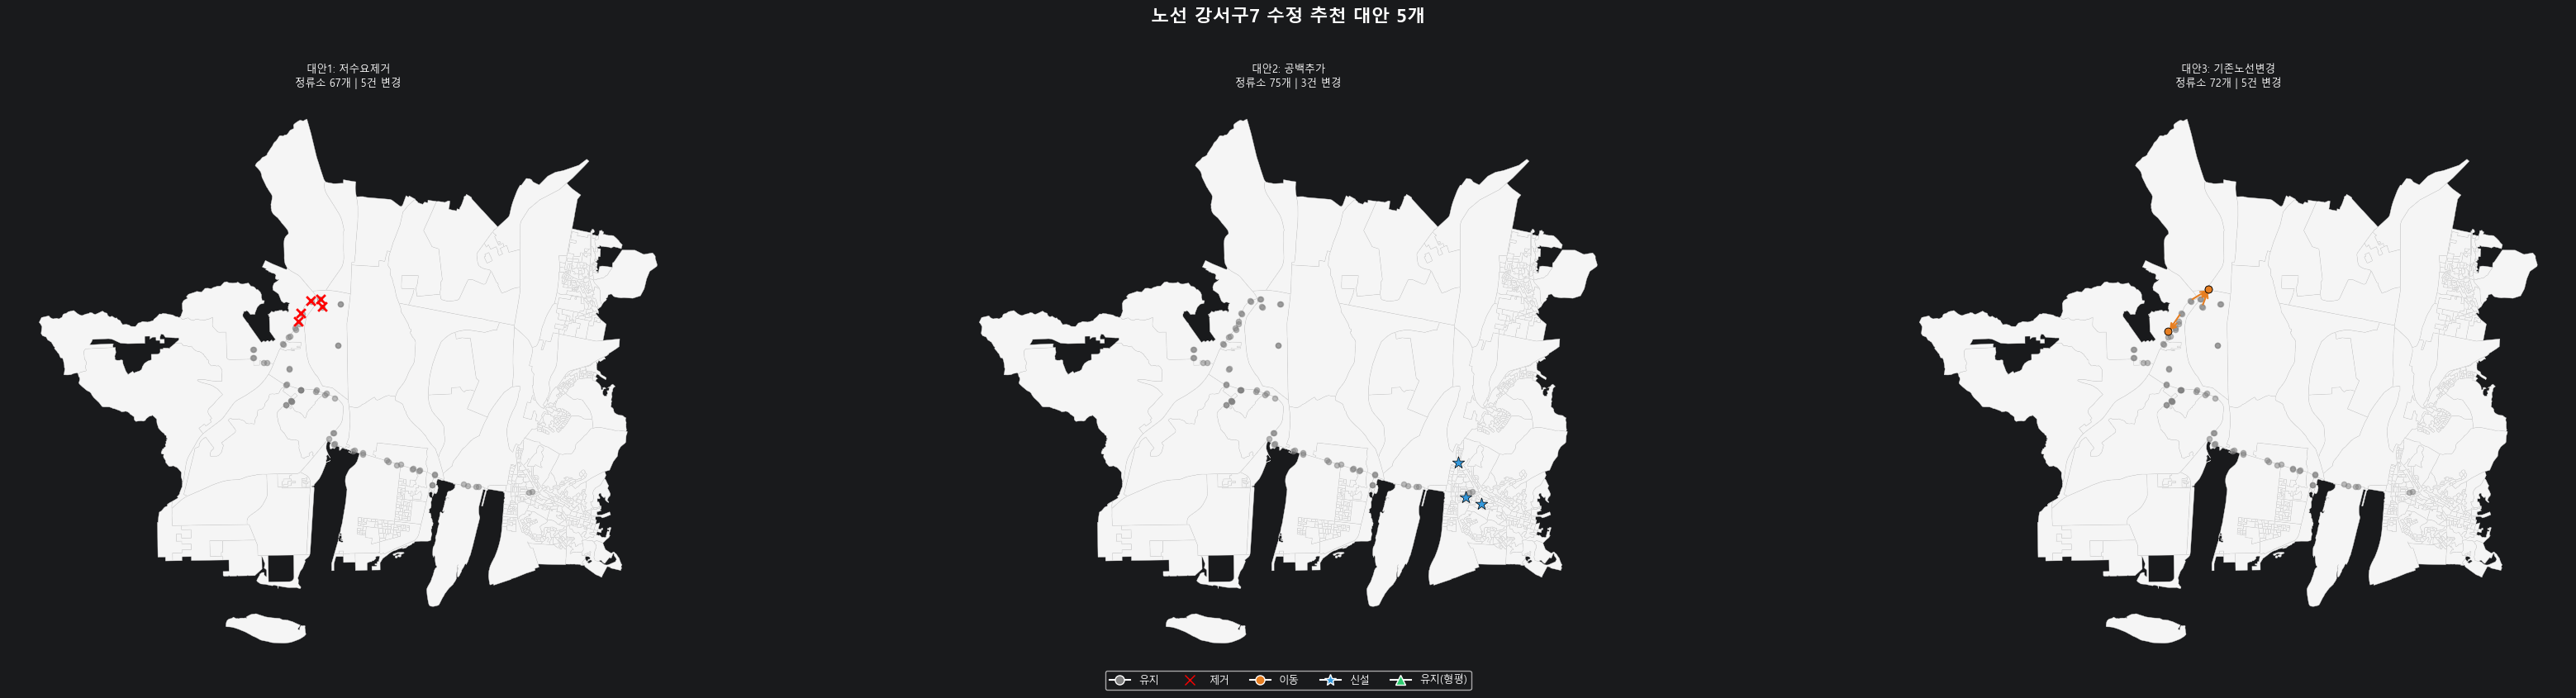

저장: 노선_강서구7_5대안_비교.png


In [118]:
# ===========================================================
# 시각화: 노선별 정류장 변경 제안 (5대안 비교) - v1.2 스타일
# ===========================================================
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(35, 8))
fig.suptitle(f'노선 {TARGET_ROUTE} 수정 추천 대안 5개', fontsize=16, fontweight='bold', y=1.02)

for idx, (alt, ax) in enumerate(zip(alternatives, axes)):
    # 배경
    route_bbox = route_stops.total_bounds
    margin = 2000
    bg = census.cx[route_bbox[0]-margin:route_bbox[2]+margin, route_bbox[1]-margin:route_bbox[3]+margin]
    if len(bg) > 0:
        bg.plot(ax=ax, color='#f5f5f5', edgecolor='#ddd', linewidth=0.3)

    # 전체 정류소 (유지 = 회색)
    keep_ids = set(alt['정류소목록']) - set(alt['제거']) - set(f'NEW_{a["node_id"]}' for a in alt['추가'])
    keep = route_stops[route_stops['정류소ID'].isin(keep_ids)]
    if len(keep) > 0:
        keep.plot(ax=ax, color='gray', markersize=20, alpha=0.5, zorder=3)

    # 제거 (빨간 X)
    if alt['제거']:
        rm = route_stops[route_stops['정류소ID'].isin(alt['제거'])]
        if len(rm) > 0:
            ax.scatter(rm.geometry.x, rm.geometry.y, c='red', marker='x', s=60, linewidth=2, zorder=5)

    # 이동 (주황 화살표)
    for mv in alt['이동']:
        si = route_stops[route_stops['정류소ID'] == mv['기존정류소ID']]
        if len(si) > 0:
            ox, oy = si.iloc[0].geometry.x, si.iloc[0].geometry.y
            ax.annotate('', xy=(mv['신규X'], mv['신규Y']), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5), zorder=4)
            ax.scatter([mv['신규X']], [mv['신규Y']], c='#e67e22', marker='o', s=40, edgecolors='black', linewidth=0.5, zorder=5)

    # 추가 (파란 별)
    for ad in alt['추가']:
        ax.scatter([ad['x']], [ad['y']], c='#3498db', marker='*', s=120, edgecolors='black', linewidth=0.5, zorder=5)

    # 형평 유지 (초록 삼각)
    eq_ids = [s for s, info in move_candidates.items() if info['has_equity']]
    if eq_ids:
        eq = route_stops[route_stops['정류소ID'].isin(eq_ids)]
        if len(eq) > 0:
            ax.scatter(eq.geometry.x, eq.geometry.y, c='#2ecc71', marker='^', s=50, edgecolors='black', linewidth=0.5, zorder=5)

    nc = len(alt['제거'])+len(alt['이동'])+len(alt['추가'])
    ax.set_title(f'대안{idx+1}: {alt["대안명"].split("_")[1]}\n정류소 {len(alt["정류소목록"])}개 | {nc}건 변경', fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

# 범례
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='유지'),
    Line2D([0],[0], marker='x', color='red', markersize=8, linestyle='None', label='제거'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e67e22', markersize=8, label='이동'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='#3498db', markersize=10, label='신설'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#2ecc71', markersize=8, label='유지(형평)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\노선_{TARGET_ROUTE}_5대안_비교.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: 노선_{TARGET_ROUTE}_5대안_비교.png')

---
## Part 3. 시나리오 2 - 심야 버스 정류소 필요 지점 표시

심야 시간대(0~5시) 수요 분석 + 기존 심야 노선 커버리지 분석을 통해
**심야 정류소가 필요한 위치**를 식별하고 지도에 표시합니다.

### 3-1. 심야 수요 분석

In [106]:
# ===========================================================
# 심야(0~5시) 교통카드 이용량 분석
# ===========================================================
print('=== 심야 수요 분석 (0~5시) ===')

night_card = card_df[card_df['심야여부']].copy()
night_bus = night_card[night_card['수단'] == '버스'].copy()
night_subway = night_card[night_card['수단'] == '지하철'].copy()

print(f'심야 전체 거래: {len(night_card):,}건')
print(f'  버스: {len(night_bus):,}건')
print(f'  지하철: {len(night_subway):,}건')

# 기존 심야 버스 노선 존재 여부
night_routes = night_bus[night_bus['transport_name'].astype(str).str.contains('심야', na=False)]
existing_night_routes = night_routes['transport_name'].unique()
print(f'\n기존 심야 버스 노선: {len(existing_night_routes)}개')
for r in existing_night_routes:
    cnt = (night_routes['transport_name'] == r).sum()
    print(f'  {r}: {cnt:,}건')

# 심야 비-심야노선 이용현황
non_night_routes_usage = night_bus[~night_bus['transport_name'].astype(str).str.contains('심야', na=False)]
print(f'\n심야 시간 비-심야노선 이용: {len(non_night_routes_usage):,}건')
print(f'  이용 노선 수: {non_night_routes_usage["transport_name"].nunique()}')

=== 심야 수요 분석 (0~5시) ===
심야 전체 거래: 1,515,213건
  버스: 823,652건
  지하철: 691,561건

기존 심야 버스 노선: 10개
  1001(심야): 4,140건
  182(심야): 50건
  1000(심야): 256건
  141(심야): 5,308건
  183(심야): 1,309건
  1002(심야): 2,828건
  1003(심야): 7,635건
  58-1(심야): 736건
  2(심야): 2,736건
  1004(심야): 2,219건

심야 시간 비-심야노선 이용: 796,435건
  이용 노선 수: 252


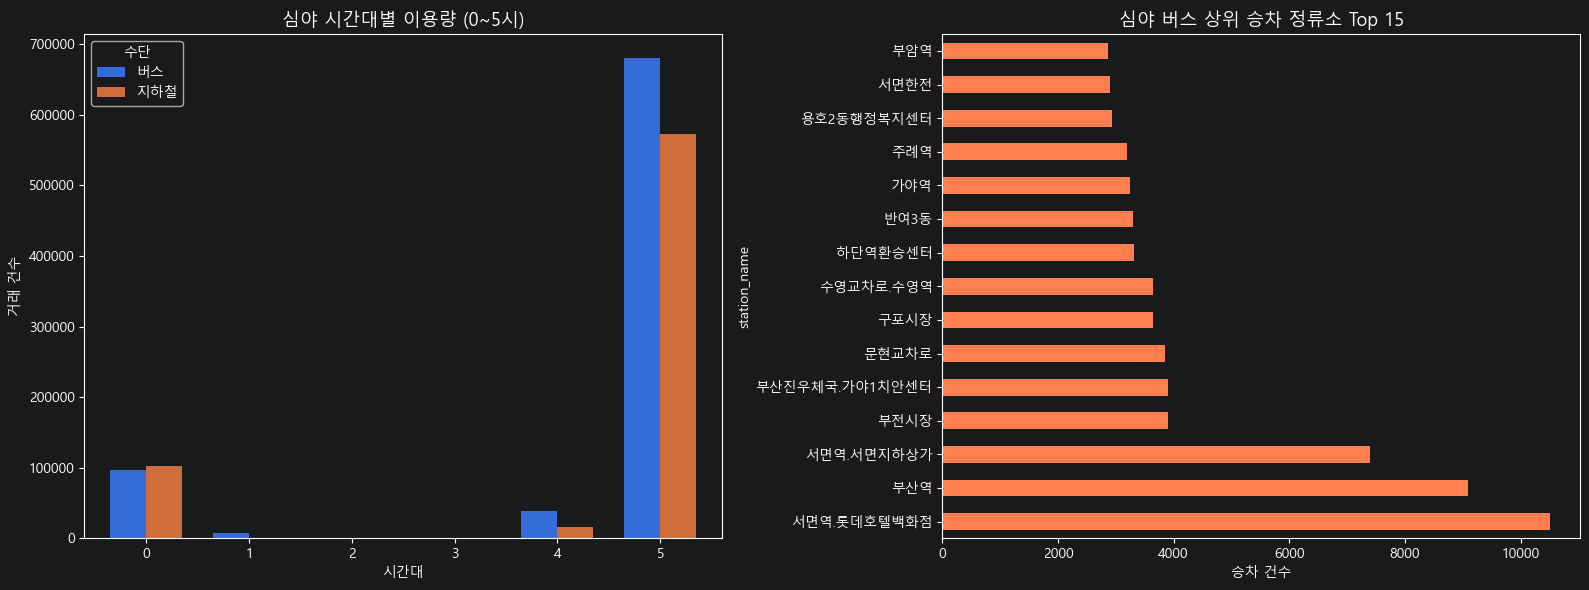

In [92]:
# 심야 시간대별 이용량 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시간대별 (0~5시 세분화)
night_hourly = night_card.groupby(['시간대', '수단']).size().unstack(fill_value=0)
night_hourly.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('심야 시간대별 이용량 (0~5시)', fontsize=13)
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('거래 건수')
axes[0].tick_params(axis='x', rotation=0)

# 심야 버스 상위 정류소
night_bus_boarding = night_bus[night_bus['승하차'] == '승차']
top_night_stops = night_bus_boarding.groupby('station_name').size().nlargest(15)
top_night_stops.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('심야 버스 상위 승차 정류소 Top 15', fontsize=13)
axes[1].set_xlabel('승차 건수')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\fig_night_demand.png', dpi=150, bbox_inches='tight')
plt.show()

In [93]:
# 심야 생활인구 + 카드소비 연계 분석
print('=== 심야 생활인구 + 카드소비 연계 ===')

# 심야 카드소비 (시간대 0~5)
night_consume = card_consume_tme[card_consume_tme['tme'].isin([0, 1, 2, 3, 4, 5])]
night_consume_grid = night_consume.groupby('id').agg(
    심야소비금액=('amt', 'sum'),
    심야소비건수=('cnt', 'sum')
).reset_index()

print(f'심야 카드소비 격자 수: {len(night_consume_grid):,}')
print(f'심야 총 소비금액: {night_consume_grid["심야소비금액"].sum():,.0f}원')

# 격자에 심야 데이터 병합 (타입 맞춤)
grid_night_pop['id'] = grid_night_pop['id'].astype(str)  # int64 -> str
night_consume_grid['id'] = night_consume_grid['id'].astype(str)  # int64 -> str

grid_night = grid_50m.merge(grid_night_pop, on='id', how='left')
grid_night = grid_night.merge(night_consume_grid, on='id', how='left')
grid_night['평균심야인구'] = grid_night['평균심야인구'].fillna(0)
grid_night['심야소비금액'] = grid_night['심야소비금액'].fillna(0)

# 심야 수요 종합 점수
grid_night['심야수요점수'] = (
        normalize(grid_night['평균심야인구']) * 0.6 +
        normalize(grid_night['심야소비금액']) * 0.4
)

print(f'심야 수요 점수 통계:')
print(grid_night['심야수요점수'].describe().round(4))


=== 심야 생활인구 + 카드소비 연계 ===
심야 카드소비 격자 수: 13,086
심야 총 소비금액: 57,503,858,685원
심야 수요 점수 통계:
count    310241.0000
mean          0.0048
std           0.0139
min           0.0000
25%           0.0000
50%           0.0002
75%           0.0025
max           0.6224
Name: 심야수요점수, dtype: float64


### 3-2. 심야 서비스 공백 분석

In [94]:
# ===========================================================
# 기존 심야 노선 커버리지 (400m 버퍼)
# ===========================================================
print('=== 심야 서비스 공백 분석 ===')

# 기존 심야 노선 정류소
night_route_stops = bus_routes_gdf[
    bus_routes_gdf['노선번호'].astype(str).str.contains('심야')
]

if len(night_route_stops) > 0:
    night_buffer = unary_union(night_route_stops.geometry.buffer(400))
    print(f'기존 심야 노선 정류소 수: {len(night_route_stops):,}')

    # 커버 영역 내/외 격자 분류
    grid_night['심야커버'] = grid_night.geometry.intersects(night_buffer)
else:
    print('기존 심야 노선 정류소 없음 (노선명 매칭 실패 가능)')
    # transport_name 기반으로 재탐색
    night_transport_names = [str(r) for r in existing_night_routes]
    night_route_stops_alt = bus_routes_gdf[
        bus_routes_gdf['노선번호'].isin(night_transport_names)
    ]
    if len(night_route_stops_alt) > 0:
        night_route_stops = night_route_stops_alt
        night_buffer = unary_union(night_route_stops.geometry.buffer(400))
        grid_night['심야커버'] = grid_night.geometry.intersects(night_buffer)
        print(f'대안 매칭: {len(night_route_stops):,}개 정류소')
    else:
        grid_night['심야커버'] = False
        night_buffer = None
        print('심야 노선 정류소 매칭 불가 - 전체를 공백으로 처리')

# 심야 수요 있지만 서비스 안 되는 공백 지역
# 수요 있음 = 심야수요점수 상위 30%
demand_threshold = grid_night['심야수요점수'].quantile(0.70)
grid_night['수요있음'] = grid_night['심야수요점수'] >= demand_threshold
grid_night['공백지역'] = grid_night['수요있음'] & ~grid_night['심야커버']

print(f'\n심야 수요 있는 격자: {grid_night["수요있음"].sum():,}개')
print(f'기존 서비스 커버 격자: {grid_night["심야커버"].sum():,}개')
print(f'공백 지역 (수요 있지만 서비스 없음): {grid_night["공백지역"].sum():,}개')

=== 심야 서비스 공백 분석 ===
기존 심야 노선 정류소 수: 1,749

심야 수요 있는 격자: 93,073개
기존 서비스 커버 격자: 63,714개
공백 지역 (수요 있지만 서비스 없음): 46,920개


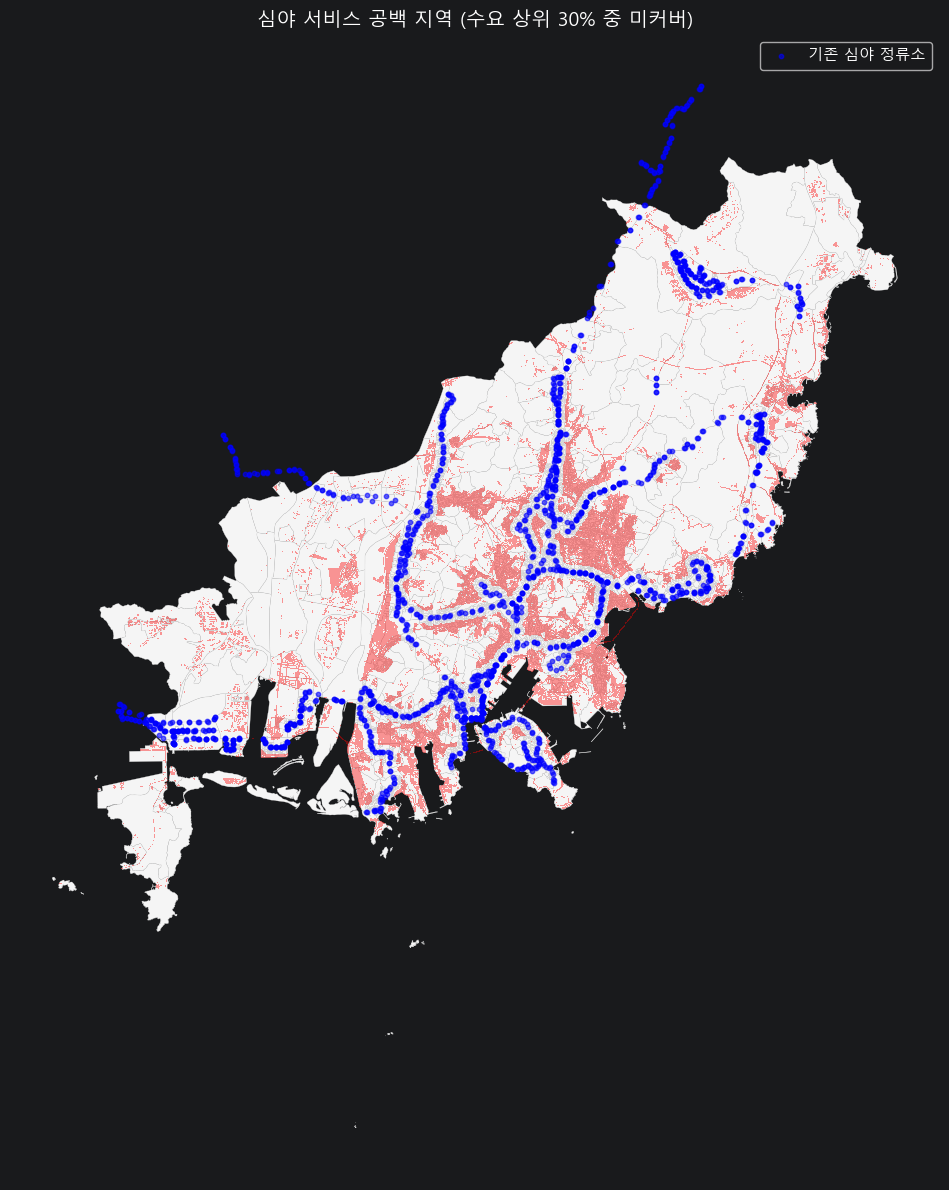

In [95]:
# 공백 지역 시각화
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# 배경
census.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.2)

# 공백 지역 표시
gap_grids = grid_night[grid_night['공백지역']]
if len(gap_grids) > 0:
    gap_grids.plot(ax=ax, color='red', alpha=0.4, label='공백 지역')

# 기존 심야 노선
if len(night_route_stops) > 0:
    night_route_stops.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='기존 심야 정류소')

ax.set_title('심야 서비스 공백 지역 (수요 상위 30% 중 미커버)', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\fig_night_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3-3. 심야 정류소 필요 지점 식별 및 표시

공백 지역의 수요 클러스터를 분석하고, 정류소가 필요한 지점을 식별합니다.

In [96]:
# ===========================================================
# 심야 공백 지역 클러스터링 (DBSCAN)
# ===========================================================
print('=== 심야 공백 지역 클러스터링 ===')

gap_grids_valid = gap_grids.copy()
gap_grids_valid['cx'] = gap_grids_valid.geometry.centroid.x
gap_grids_valid['cy'] = gap_grids_valid.geometry.centroid.y

coords = gap_grids_valid[['cx', 'cy']].values

db = DBSCAN(eps=500, min_samples=5)
gap_grids_valid['cluster'] = db.fit_predict(coords)

clusters_df = gap_grids_valid[gap_grids_valid['cluster'] >= 0]
n_clusters = clusters_df['cluster'].nunique()

id_col = [c for c in gap_grids_valid.columns if c not in ['cx','cy','cluster','geometry','심야수요점수','심야커버','수요있음','공백지역']][0]

cluster_info = clusters_df.groupby('cluster').agg(
    격자수=(id_col, 'count'),
    평균수요=('심야수요점수', 'mean'),
    총수요=('심야수요점수', 'sum'),
    중심X=('cx', 'mean'),
    중심Y=('cy', 'mean')
).reset_index()
cluster_info = cluster_info.sort_values('총수요', ascending=False).reset_index(drop=True)

print(f'클러스터 수: {n_clusters}')
print(f'노이즈: {(gap_grids_valid["cluster"] == -1).sum()}')
print(f'\n상위 10 클러스터:')
print(cluster_info.head(10).to_string(index=False))


=== 심야 공백 지역 클러스터링 ===
클러스터 수: 67
노이즈: 101

상위 10 클러스터:
 cluster  격자수     평균수요        총수요          중심X          중심Y
      41 7131 0.017765 126.684041 1.139828e+06 1.689992e+06
       6 5974 0.019348 115.584144 1.148068e+06 1.689199e+06
       0 7398 0.014153 104.707485 1.145422e+06 1.683091e+06
       3 5693 0.006270  35.696333 1.132296e+06 1.684888e+06
      39 3434 0.010368  35.603150 1.136277e+06 1.677199e+06
      58 2504 0.011435  28.632701 1.145914e+06 1.693982e+06
      42 2008 0.012693  25.486766 1.139410e+06 1.683838e+06
       5 4498 0.004871  21.911495 1.156233e+06 1.698522e+06
       2 1588 0.008558  13.590784 1.132500e+06 1.676791e+06
      53  314 0.018755   5.888964 1.143269e+06 1.690131e+06


In [97]:
# ===========================================================
# 심야 정류소 필요 지점 식별
# ===========================================================
print('=== 심야 정류소 필요 지점 식별 ===')

stop_coords_arr = np.column_stack([bus_stops_shp.geometry.x.values, bus_stops_shp.geometry.y.values])
stop_tree_night = cKDTree(stop_coords_arr)

if 'car_node_tree' not in dir():
    car_node_coords = np.array([(G_car.nodes[n].get('x',0), G_car.nodes[n].get('y',0)) for n in G_car.nodes()])
    car_node_ids = list(G_car.nodes())
    car_node_tree = cKDTree(car_node_coords)

night_stop_needs = []
for _, cl in cluster_info.iterrows():
    cx, cy = cl['중심X'], cl['중심Y']
    dist_nearest, nearest_idx = stop_tree_night.query([cx, cy])
    ns = bus_stops_shp.iloc[nearest_idx]
    _, ni = car_node_tree.query([cx, cy])
    sn = car_node_ids[ni]
    sx, sy = G_car.nodes[sn].get('x', cx), G_car.nodes[sn].get('y', cy)
    
    gd = np.sqrt((grid_50m.geometry.centroid.x - cx)**2 + (grid_50m.geometry.centroid.y - cy)**2)
    ngi = gd.idxmin()
    ngid = grid_50m.loc[ngi, 'id']
    em = grid_emd[grid_emd['id'] == ngid]
    ecd = em['EMD_CD'].values[0] if len(em) > 0 and pd.notna(em['EMD_CD'].values[0]) else None
    
    night_stop_needs.append({
        'NEED_PK': f'NSN_{int(cl["cluster"]):04d}', 'cluster_id': int(cl['cluster']),
        '중심X': cx, '중심Y': cy, '스냅X': sx, '스냅Y': sy,
        '스냅노드ID': sn, 'NODE_PK': f'NDE_{sn}', 'GRID_PK': f'GRD_{ngid}',
        '격자수': cl['격자수'], '총수요점수': cl['총수요'], '평균수요점수': cl['평균수요'],
        '최근접정류소': ns.get('bstopnm', str(ns['bstopid'])),
        '최근접정류소거리_m': dist_nearest, 'STOP_PK_nearest': f'STP_{ns["bstopid"]}',
        'EMD_CD': ecd, 'EMD_PK': f'EMD_{ecd}' if ecd else None
    })

night_needs_df = pd.DataFrame(night_stop_needs)
night_needs_df['우선순위점수'] = night_needs_df['총수요점수'] * (night_needs_df['최근접정류소거리_m'] / 1000)
night_needs_df['우선순위'] = night_needs_df['우선순위점수'].rank(ascending=False, method='min').astype(int)
night_needs_df = night_needs_df.sort_values('우선순위')

print(f'필요 지점: {len(night_needs_df)}개')
print(f'\n상위 20개:')
print(night_needs_df[['우선순위','NEED_PK','총수요점수','최근접정류소','최근접정류소거리_m','EMD_CD']].head(20).to_string(index=False))

=== 심야 정류소 필요 지점 식별 ===
필요 지점: 67개

상위 20개:
 우선순위  NEED_PK      총수요점수      최근접정류소  최근접정류소거리_m   EMD_CD
    1 NSN_0041 126.684041      만덕고등학교  724.327818 21050550
    2 NSN_0000 104.707485      유엔조각공원  298.898636 21070700
    3 NSN_0058  28.632701  BMC아파트120동  927.985667 21110730
    4 NSN_0039  35.603150     감천항제5부두  369.924698      NaN
    5 NSN_0005  21.911495      일광초등학교  547.427649 21510111
    6 NSN_0006 115.584144      재송시장입구   92.833925 21090640
    7 NSN_0042  25.486766     동의대학교본관  312.210057 21050810
    8 NSN_0003  35.696333    맥도자연생태공원  116.630341 21120520
    9 NSN_0064   4.456852       삼한아파트  360.401000 21090620
   10 NSN_0043   2.455746       북부경찰서  531.486660 21080630
   11 NSN_0010   0.417903        가동마을 3112.469435 21510130
   12 NSN_0029   2.598989       세산삼거리  496.086225 21120560
   13 NSN_0002  13.590784        도시가스   84.290310 21100600
   14 NSN_0008   0.407415     경찰특공대입구 2335.321228 21090690
   15 NSN_0051   0.846457       경동아파트  730.470432 21110670
   16 NSN_00

In [98]:
# (심야 노선 설계 제거됨 - 필요 지점 표시만)
pass

In [99]:
# (심야 노선 설계 제거됨)
pass

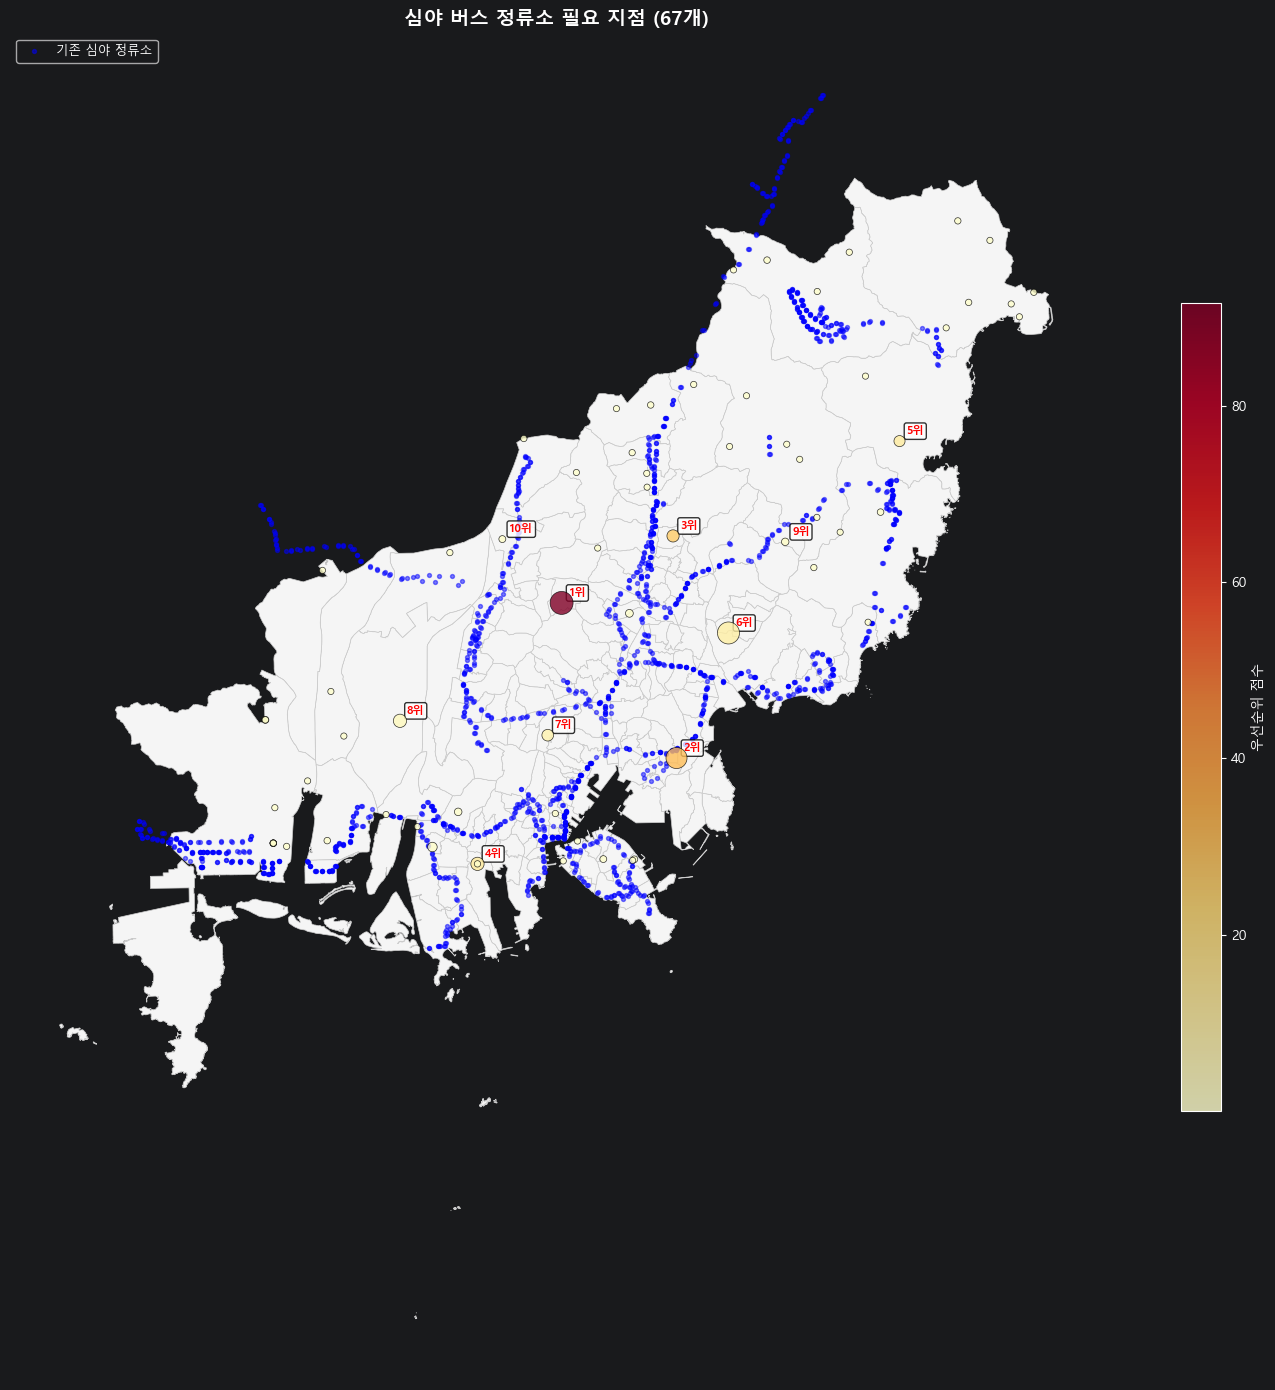

In [100]:
# ===========================================================
# 심야 정류소 필요 지점 시각화
# ===========================================================
fig, ax = plt.subplots(1, 1, figsize=(16, 14))

if 'emd_boundary' in dir():
    emd_boundary.plot(ax=ax, color='#f5f5f5', edgecolor='#ccc', linewidth=0.5)
else:
    census.plot(ax=ax, color='#f5f5f5', edgecolor='#ddd', linewidth=0.3)

night_routes = bus_routes_gdf[bus_routes_gdf['노선번호'].astype(str).str.contains('심야|N', case=False, na=False)]
if len(night_routes) > 0:
    night_routes.plot(ax=ax, color='blue', markersize=8, alpha=0.5, label='기존 심야 정류소')

if 'night_coverage' in dir() and night_coverage is not None:
    try:
        gpd.GeoDataFrame(geometry=[night_coverage], crs=TARGET_CRS).plot(ax=ax, color='lightblue', alpha=0.2, label='기존 커버리지(400m)')
    except: pass

needs_gdf = gpd.GeoDataFrame(night_needs_df, geometry=gpd.points_from_xy(night_needs_df['스냅X'], night_needs_df['스냅Y']), crs=TARGET_CRS)
scatter = ax.scatter(needs_gdf.geometry.x, needs_gdf.geometry.y, c=needs_gdf['우선순위점수'], cmap='YlOrRd',
    s=needs_gdf['총수요점수']*2+20, edgecolors='black', linewidth=0.5, alpha=0.8, zorder=5)
plt.colorbar(scatter, ax=ax, label='우선순위 점수', shrink=0.6)

for _, row in night_needs_df.head(10).iterrows():
    ax.annotate(f'{int(row["우선순위"])}위', xy=(row['스냅X'], row['스냅Y']),
        xytext=(5,5), textcoords='offset points', fontsize=8, fontweight='bold', color='red',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_title(f'심야 버스 정류소 필요 지점 ({len(night_needs_df)}개)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\심야_정류소_필요지점.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4. 종합 결과 저장

In [101]:
# ===========================================================
# 결과 CSV 저장 (PK 체계 포함)
# ===========================================================
print('=== 결과 저장 ===')

eff_save = efficiency.copy()
if 'ROUTE_PK' not in eff_save.columns:
    eff_save['ROUTE_PK'] = 'RTE_' + eff_save['노선번호'].astype(str)
save_cols = ['ROUTE_PK','노선번호','노선유형','정류소수','노선길이_km','일평균승차량',
             '수요효율','커버리지효율','중복도','CV','첨두비율','사회형평점수','경제활동밀도','종합효율점수','효율순위']
eff_save[[c for c in save_cols if c in eff_save.columns]].to_csv(f'{RESULT_DIR}\\노선별_효율성점수.csv', index=False, encoding='utf-8-sig')
print(f'1) 노선별_효율성점수.csv ({len(eff_save)}건)')

alt_summary.to_csv(f'{RESULT_DIR}\\노선수정_대안요약.csv', index=False, encoding='utf-8-sig')
print(f'2) 노선수정_대안요약.csv ({len(alt_summary)}건)')

if len(changes_df) > 0:
    changes_df.to_csv(f'{RESULT_DIR}\\노선수정_변경상세.csv', index=False, encoding='utf-8-sig')
    print(f'3) 노선수정_변경상세.csv ({len(changes_df)}건)')

if 'trip_pairs_estimated' in dir():
    es = trip_pairs_estimated['추정방법'].value_counts().reset_index()
    es.columns = ['추정방법','건수']
    es.to_csv(f'{RESULT_DIR}\\하차추정_통계.csv', index=False, encoding='utf-8-sig')
    print(f'4) 하차추정_통계.csv')

night_needs_df.to_csv(f'{RESULT_DIR}\\심야_정류소_필요지점.csv', index=False, encoding='utf-8-sig')
print(f'5) 심야_정류소_필요지점.csv ({len(night_needs_df)}건)')

grid_emd.to_csv(f'{RESULT_DIR}\\Grid_읍면동_매핑.csv', index=False, encoding='utf-8-sig')
print(f'6) Grid_읍면동_매핑.csv ({len(grid_emd)}건)')

stop_emd.to_csv(f'{RESULT_DIR}\\정류소_읍면동_매핑.csv', index=False, encoding='utf-8-sig')
print(f'7) 정류소_읍면동_매핑.csv ({len(stop_emd)}건)')

pk_master = pd.DataFrame({'PK유형':['GRID_PK','EMD_PK','STOP_PK','ROUTE_PK','NODE_PK','LINK_PK'],
    '포맷':['GRD_{id}','EMD_{ADM_CD}','STP_{bstopid}','RTE_{노선번호}','NDE_{NODE_ID}','LNK_{LINK_ID}'],
    '건수':[len(grid_50m),len(emd_boundary),len(bus_stops_shp),bus_routes_gdf['ROUTE_PK'].nunique(),G_car.number_of_nodes(),G_car.number_of_edges()]})
pk_master.to_csv(f'{RESULT_DIR}\\PK_마스터.csv', index=False, encoding='utf-8-sig')
print(f'8) PK_마스터.csv')

print(f'\n저장 완료: {RESULT_DIR}')
for fn in sorted(os.listdir(RESULT_DIR)):
    print(f'  {fn} ({os.path.getsize(os.path.join(RESULT_DIR,fn))/1024:.1f} KB)')

=== 결과 저장 ===
1) 노선별_효율성점수.csv (326건)
2) 노선수정_대안요약.csv (5건)
3) 노선수정_변경상세.csv (179건)
4) 하차추정_통계.csv
5) 심야_정류소_필요지점.csv (67건)
6) Grid_읍면동_매핑.csv (310241건)
7) 정류소_읍면동_매핑.csv (8522건)
8) PK_마스터.csv

저장 완료: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터\results_optimization
  Grid_읍면동_매핑.csv (12162.7 KB)
  PK_마스터.csv (0.2 KB)
  fig_night_demand.png (84.8 KB)
  fig_night_gap.png (523.3 KB)
  night_route_summary.csv (0.3 KB)
  night_route_심야신설1호.png (1216.3 KB)
  night_route_심야신설2호.png (595.2 KB)
  night_route_심야신설3호.png (1214.4 KB)
  night_route_심야신설4호.png (1228.6 KB)
  night_route_심야신설5호.png (1238.8 KB)
  route_55_proposal.png (620.7 KB)
  route_강서구12-1_proposal.png (553.5 KB)
  route_강서구6-1_proposal.png (367.9 KB)
  route_강서구7_proposal.png (655.4 KB)
  route_강서구9-1_proposal.png (415.9 KB)
  노선_강서구7_5대안_비교.png (436.5 KB)
  노선별_효율성점수.csv (63.5 KB)
  노선수정_대안요약.csv (0.5 KB)
  노선수정_변경상세.csv (24.5 KB)
  비효율노선_Top10.csv (2.1 KB)
  심야_공백_클러스터.csv (5.5 KB)
  심야_정류소_필요지점.csv (16.6 KB)
  심야_정류소_필요지점.png (4